In [1]:
import time
from dataclasses import dataclass
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import seaborn as sns
from prince import MCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

try:
    import plotly.graph_objects as go
except ImportError:
    go = None


In [2]:
@dataclass
class DiseaseData:
    X_numeric: pd.DataFrame
    X_categorical: pd.DataFrame
    disease_cols: list[str]
    mask: np.ndarray
    period_name: str = "all_time"
    date_cols: list[str] | None = None


In [3]:
@dataclass
class PeriodSample:
    period_name: str
    cutoff_date: pd.Timestamp | None
    active_disease_data: DiseaseData
    status_df: pd.DataFrame
    sample_summary: dict


In [4]:
def _elapsed(start_time):
    seconds = time.time() - start_time
    return seconds, str(timedelta(seconds=int(seconds)))


In [5]:
def _cluster_size_table(labels):
    labels = np.asarray(labels)
    counts = np.bincount(labels)
    table = pd.DataFrame(
        {
            "cluster": np.arange(len(counts)),
            "n_patients": counts,
        }
    )
    table["percentage"] = table["n_patients"] / len(labels) * 100
    return table


In [6]:
def _evaluation_metrics(X, labels, seed=42, silhouette_sample_size=10000):
    """
    Compute clustering metrics.

    silhouette_score is O(n^2) by default. For large datasets, sampling makes it
    much faster while still useful for comparing parameter combinations.
    """
    n_samples = len(labels)
    n_labels = len(np.unique(labels))
    if not 1 < n_labels < n_samples:
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": 0,
            "metric_warning": (
                f"Invalid number of labels for clustering metrics: {n_labels}"
            ),
        }

    sample_size = None
    if silhouette_sample_size and n_samples > silhouette_sample_size:
        sample_size = silhouette_sample_size

    return {
        "silhouette_score": silhouette_score(
            X,
            labels,
            sample_size=sample_size,
            random_state=seed,
        ),
        "davies_bouldin_index": davies_bouldin_score(X, labels),
        "calinski_harabasz_index": calinski_harabasz_score(X, labels),
        "silhouette_sample_size": sample_size or n_samples,
    }


In [7]:
def _sample_indices(n_samples, sample_size=10000, seed=42):
    if sample_size is None or n_samples <= sample_size:
        return np.arange(n_samples)
    rng = np.random.default_rng(seed)
    return rng.choice(n_samples, size=sample_size, replace=False)


In [8]:
def _jaccard_distance_to_centers(X_binary, centers_binary):
    """
    Compute Jaccard distance from binary samples to binary prototypes.

    X_binary shape: samples x diseases
    centers_binary shape: clusters x diseases
    """
    X_binary = np.asarray(X_binary, dtype=np.uint8)
    centers_binary = np.asarray(centers_binary, dtype=np.uint8)

    intersection = X_binary @ centers_binary.T
    x_sum = X_binary.sum(axis=1, keepdims=True)
    center_sum = centers_binary.sum(axis=1).reshape(1, -1)
    union = x_sum + center_sum - intersection

    similarity = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0,
    )
    return 1.0 - similarity


In [9]:
def _jaccard_silhouette_score(
    X_binary,
    labels,
    seed=42,
    silhouette_sample_size=10000,
):
    labels = np.asarray(labels)
    n_labels = len(np.unique(labels))
    if not 1 < n_labels < len(labels):
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": 0,
            "metric_warning": (
                f"Invalid number of labels for Jaccard silhouette: {n_labels}"
            ),
        }

    sample_idx = _sample_indices(
        n_samples=len(labels),
        sample_size=silhouette_sample_size,
        seed=seed,
    )
    sampled_labels = labels[sample_idx]
    sampled_n_labels = len(np.unique(sampled_labels))
    if not 1 < sampled_n_labels < len(sample_idx):
        return {
            "silhouette_score": np.nan,
            "davies_bouldin_index": np.nan,
            "calinski_harabasz_index": np.nan,
            "silhouette_sample_size": len(sample_idx),
            "metric_warning": (
                "Invalid number of labels in silhouette sample: "
                f"{sampled_n_labels}"
            ),
        }

    return {
        "silhouette_score": silhouette_score(
            X_binary[sample_idx].astype(bool),
            sampled_labels,
            metric="jaccard",
        ),
        "davies_bouldin_index": np.nan,
        "calinski_harabasz_index": np.nan,
        "silhouette_sample_size": len(sample_idx),
    }


In [10]:
def _format_float_for_filename(value):
    return str(value).replace(".", "p")


In [11]:
def _extract_condition_key(column_name):
    """
    Extract the shared disease key from B_MEDI / BD_MEDI column names.

    Example:
    B_MEDI:HF_BHAM_CAM_FINAL:0 -> HF_BHAM_CAM_FINAL:0
    BD_MEDI:HF_BHAM_CAM_FINAL:0 -> HF_BHAM_CAM_FINAL:0
    """
    return str(column_name).split(":", 1)[1] if ":" in str(column_name) else str(column_name)


In [12]:
def _find_disease_date_pairs(
    columns,
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
):
    disease_cols = [col for col in columns if str(col).startswith(disease_prefix)]
    date_cols = [col for col in columns if str(col).startswith(date_prefix)]
    date_by_key = {_extract_condition_key(col): col for col in date_cols}

    pairs = []
    for disease_col in disease_cols:
        key = _extract_condition_key(disease_col)
        date_col = date_by_key.get(key)
        if date_col is not None:
            pairs.append((disease_col, date_col))

    if not pairs:
        raise ValueError(
            "No B_MEDI / BD_MEDI disease-date pairs found. "
            "Please check disease_prefix and date_prefix."
        )

    return pairs


In [13]:
def _excel_col_to_index(excel_col):
    value = 0
    for char in excel_col.upper():
        value = value * 26 + (ord(char) - ord("A") + 1)
    return value - 1


In [14]:
def _find_final_disease_columns_from_excel_start(columns, start_excel_col="FT"):
    start_idx = _excel_col_to_index(start_excel_col)
    selected_cols = list(columns[start_idx:])
    disease_cols = [col for col in selected_cols if str(col).startswith("B.M.")]
    if not disease_cols:
        raise ValueError(
            f"No B.M. final disease columns found from Excel column {start_excel_col}."
        )
    return disease_cols


In [15]:
def _parse_cutoff_date(cutoff_date):
    if cutoff_date is None:
        return None
    return pd.Timestamp(cutoff_date)


In [16]:
def _date_le_cutoff(date_series, cutoff_date):
    dates = pd.to_datetime(date_series, errors="coerce")
    if cutoff_date is None:
        return dates.notna()
    return dates.notna() & (dates <= cutoff_date)


In [17]:
def _date_in_or_before_period(date_series, cutoff_date):
    dates = pd.to_datetime(date_series, errors="coerce")
    if cutoff_date is None:
        return dates.notna()
    return dates.notna() & (dates <= cutoff_date)


In [18]:
def _period_mask_from_years(years, start_year=None, end_year=None):
    mask = years.notna()
    if start_year is not None:
        mask &= years >= start_year
    if end_year is not None:
        mask &= years < end_year
    return mask


In [19]:
def load_disease_data_by_period(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    period_name="before_2005",
    start_year=None,
    end_year=2005,
    period_mode="cumulative",
    min_disease_count=2,
):
    """
    Build a disease 0/1 matrix for one diagnosis-time period.

    period_mode controls how disease dates are interpreted:
    - cumulative: disease persists after diagnosis; period status is disease
      diagnosed before the period end year.
    - incident: only diseases first diagnosed inside the period are counted.

    Period boundaries use start-inclusive, end-exclusive years. With the default
    cumulative mode, start_year is ignored and end_year defines the status date:
    - before_2005: diagnosis year < 2005
    - 2005_2015: diagnosis year < 2015
    - 2015_2025: diagnosis year < 2026

    A disease is coded as 1 for a patient only when:
    - the all-time disease column is 1, and
    - the matching diagnosis/check date satisfies the chosen period rule.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Reading disease data for period: {period_name}")
    print("=" * 70)

    header = pd.read_csv(csv_file, nrows=0)
    pairs = _find_disease_date_pairs(
        header.columns,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
    )
    disease_cols = [disease_col for disease_col, _date_col in pairs]
    date_cols = [date_col for _disease_col, date_col in pairs]
    usecols = disease_cols + date_cols

    df = pd.read_csv(csv_file, usecols=usecols, low_memory=False)
    X = pd.DataFrame(index=df.index)

    for disease_col, date_col in pairs:
        disease_values = pd.to_numeric(df[disease_col], errors="coerce")
        has_disease = disease_values.notna() & (disease_values != 0)
        dates = pd.to_datetime(df[date_col], errors="coerce")
        years = dates.dt.year
        if period_mode == "cumulative":
            in_period = _period_mask_from_years(
                years,
                start_year=None,
                end_year=end_year,
            )
        elif period_mode == "incident":
            in_period = _period_mask_from_years(
                years,
                start_year=start_year,
                end_year=end_year,
            )
        else:
            raise ValueError("period_mode must be 'cumulative' or 'incident'.")
        X[disease_col] = (has_disease & in_period).astype(np.int8)

    disease_count = X.sum(axis=1)
    mask = (disease_count >= min_disease_count).to_numpy()
    X = X.loc[mask].reset_index(drop=True)
    X_categorical = X.astype("category")

    seconds, pretty = _elapsed(start_time)
    print(f"Disease-date pairs: {len(pairs)}")
    print(f"Original sample size: {len(mask)}")
    print(f"Filtered sample size: {len(X)}")
    print(f"Removed sample size: {len(mask) - len(X)}")
    print(f"Data preparation time: {seconds:.2f} seconds ({pretty})")

    return DiseaseData(
        X_numeric=X,
        X_categorical=X_categorical,
        disease_cols=disease_cols,
        mask=mask,
        period_name=period_name,
        date_cols=date_cols,
    )


In [20]:
def load_period_disease_data_sets(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    min_disease_count=2,
    period_specs=None,
    period_mode="cumulative",
):
    """
    Load the three requested diagnosis-time disease matrices.
    """
    if period_specs is None:
        period_specs = {
            "before_2005": {"start_year": None, "end_year": 2005},
            "2005_2015": {"start_year": 2005, "end_year": 2015},
            "2015_2025": {"start_year": 2015, "end_year": 2026},
        }

    period_data = {}
    for period_name, spec in period_specs.items():
        period_data[period_name] = load_disease_data_by_period(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            date_prefix=date_prefix,
            period_name=period_name,
            start_year=spec.get("start_year"),
            end_year=spec.get("end_year"),
            period_mode=period_mode,
            min_disease_count=min_disease_count,
        )

    return period_data


In [21]:
def generate_period_disease_sample_files(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    min_disease_count=2,
    period_specs=None,
    period_mode="cumulative",
    output_dir="period_disease_samples",
    file_format="csv",
):
    """
    Generate and save disease 0/1 samples for each diagnosis-time period.

    This function only prepares data samples. It does not run MCA, KMeans, FCM,
    or hyperparameter tuning.

    Saved files contain:
    - original_row_index: row position in the original CSV
    - one 0/1 column per disease

    Default cumulative interpretation:
    - before_2005: diseases diagnosed before 2005
    - 2005_2015: diseases diagnosed before 2015
    - 2015_2025: diseases diagnosed before 2026
    """
    if file_format not in {"csv", "parquet"}:
        raise ValueError("file_format must be 'csv' or 'parquet'.")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    period_data_sets = load_period_disease_data_sets(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
        min_disease_count=min_disease_count,
        period_specs=period_specs,
        period_mode=period_mode,
    )

    summary_records = []
    sample_files = {}

    for period_name, disease_data in period_data_sets.items():
        sample_df = disease_data.X_numeric.copy()
        original_row_index = np.flatnonzero(disease_data.mask)
        sample_df.insert(0, "original_row_index", original_row_index)

        if file_format == "csv":
            sample_file = output_dir / f"{period_name}_disease_sample.csv"
            sample_df.to_csv(sample_file, index=False)
        else:
            sample_file = output_dir / f"{period_name}_disease_sample.parquet"
            sample_df.to_parquet(sample_file, index=False)

        disease_count = disease_data.X_numeric.sum(axis=1)
        summary_records.append(
            {
                "period": period_name,
                "period_mode": period_mode,
                "sample_file": str(sample_file),
                "n_original_rows": len(disease_data.mask),
                "n_filtered_rows": len(sample_df),
                "n_disease_columns": len(disease_data.disease_cols),
                "min_disease_count": min_disease_count,
                "mean_disease_count": disease_count.mean()
                if len(disease_count) > 0
                else np.nan,
                "median_disease_count": disease_count.median()
                if len(disease_count) > 0
                else np.nan,
            }
        )
        sample_files[period_name] = str(sample_file)
        print(f"Saved {period_name} sample to: {sample_file}")

    summary_df = pd.DataFrame(summary_records)
    summary_file = output_dir / "period_disease_sample_summary.csv"
    summary_df.to_csv(summary_file, index=False)
    print(f"Saved sample summary to: {summary_file}")

    return summary_df, sample_files


In [22]:
def generate_period_analysis_samples(
    csv_file="masterDataOptimal_v220230323015634.csv",
    final_disease_start_excel_col="FT",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    death_date_col="DEATH_DATE",
    dropout_date_col="TRANSFER_DATE",
    patient_id_col="PATIENT_ID",
    min_final_disease_count=2,
    period_cutoffs=None,
    birth_year_col="YEAR_OF_BIRTH",
    min_age=60,
    collection_date="2022-03-01",
):
    """
    Generate in-memory period samples for later tuning.

    Workflow:
    1. Use final disease columns from Excel column FT onward (B.M.* columns) to
       keep participants with at least min_final_disease_count diseases.
    1b. Additionally keep only participants with YEAR_OF_BIRTH year <= 1962,
       matching the single-period notebooks. Set min_age=None to skip this filter.
    2. For each period cutoff, classify each retained participant:
       - death: death_date <= cutoff
       - drop_out: not death, and dropout_date <= cutoff
       - active: neither death nor drop_out
    3. For active participants only, create a cumulative disease 0/1 matrix:
       a disease is 1 if its matching BD_MEDI date is <= cutoff. If cutoff is
       None, any observed diagnosis date is counted.

    Nothing is saved to disk. The returned dict can be used directly by tuning
    functions.
    """
    if period_cutoffs is None:
        period_cutoffs = {
            "before_2012_03": "2012-03-01",
            "2012_03_to_2017_03": "2017-03-01",
            "after_2017_03": None,
        }

    start_time = time.time()
    header = pd.read_csv(csv_file, nrows=0)
    all_columns = list(header.columns)

    final_disease_cols = _find_final_disease_columns_from_excel_start(
        all_columns,
        start_excel_col=final_disease_start_excel_col,
    )
    disease_date_pairs = _find_disease_date_pairs(
        all_columns,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
    )
    disease_cols = [disease_col for disease_col, _date_col in disease_date_pairs]
    date_cols = [date_col for _disease_col, date_col in disease_date_pairs]

    metadata_cols = [death_date_col, dropout_date_col]
    if patient_id_col in all_columns:
        metadata_cols.append(patient_id_col)
    if min_age is not None and birth_year_col in all_columns:
        metadata_cols.append(birth_year_col)

    usecols = list(dict.fromkeys(metadata_cols + final_disease_cols + disease_cols + date_cols))
    df = pd.read_csv(csv_file, usecols=usecols, low_memory=False)

    final_raw = df[final_disease_cols].apply(pd.to_numeric, errors="coerce")
    final_disease_matrix = (final_raw.notna() & (final_raw != 0)).astype(np.int8)
    final_disease_count = final_disease_matrix.sum(axis=1)

    disease_count_mask = (final_disease_count >= min_final_disease_count).to_numpy()

    age_mask = np.ones(len(df), dtype=bool)
    if min_age is not None:
        if birth_year_col not in df.columns:
            raise ValueError(
                f"birth_year_col={birth_year_col!r} not found in CSV columns, "
                "cannot apply age filter. Set min_age=None to skip filtering."
            )
        birth_dates = pd.to_datetime(df[birth_year_col], errors="coerce")
        age_mask = (birth_dates.notna() & (birth_dates.dt.year <= 1962)).to_numpy()

    base_mask = disease_count_mask & age_mask
    base_indices = np.flatnonzero(base_mask)

    df_base = df.loc[base_mask].reset_index(drop=True)
    original_row_index = base_indices

    period_samples = {}
    summary_records = []

    for period_name, cutoff_value in period_cutoffs.items():
        cutoff_date = _parse_cutoff_date(cutoff_value)

        death_mask = _date_le_cutoff(df_base[death_date_col], cutoff_date)
        dropout_mask = (~death_mask) & _date_le_cutoff(
            df_base[dropout_date_col],
            cutoff_date,
        )
        active_mask = ~(death_mask | dropout_mask)

        status = np.where(death_mask, "death", np.where(dropout_mask, "drop_out", "active"))
        status_df = pd.DataFrame(
            {
                "original_row_index": original_row_index,
                "status": status,
                "death_date": pd.to_datetime(df_base[death_date_col], errors="coerce"),
                "dropout_date": pd.to_datetime(df_base[dropout_date_col], errors="coerce"),
            }
        )
        if patient_id_col in df_base.columns:
            status_df.insert(1, patient_id_col, df_base[patient_id_col].to_numpy())

        X_active = pd.DataFrame(index=df_base.index[active_mask])
        for disease_col, date_col in disease_date_pairs:
            disease_values = pd.to_numeric(df_base.loc[active_mask, disease_col], errors="coerce")
            has_disease = disease_values.notna() & (disease_values != 0)
            diagnosed_by_cutoff = _date_in_or_before_period(
                df_base.loc[active_mask, date_col],
                cutoff_date,
            )
            X_active[disease_col] = (has_disease & diagnosed_by_cutoff).astype(np.int8).to_numpy()

        X_active = X_active.reset_index(drop=True)
        active_original_indices = original_row_index[active_mask.to_numpy()]
        active_disease_data = DiseaseData(
            X_numeric=X_active,
            X_categorical=X_active.astype("category"),
            disease_cols=disease_cols,
            mask=active_mask.to_numpy(),
            period_name=period_name,
            date_cols=date_cols,
        )

        active_disease_count = X_active.sum(axis=1)
        sample_summary = {
            "period": period_name,
            "cutoff_date": str(cutoff_date.date()) if cutoff_date is not None else "final_observed",
            "n_initial_rows": len(df),
            "n_base_multimorbidity_rows": len(df_base),
            "n_active": int(active_mask.sum()),
            "n_death": int(death_mask.sum()),
            "n_drop_out": int(dropout_mask.sum()),
            "n_disease_columns": len(disease_cols),
            "mean_active_disease_count": active_disease_count.mean()
            if len(active_disease_count) > 0
            else np.nan,
            "median_active_disease_count": active_disease_count.median()
            if len(active_disease_count) > 0
            else np.nan,
        }

        status_df["active_original_row_index"] = np.nan
        status_df.loc[active_mask.to_numpy(), "active_original_row_index"] = active_original_indices

        period_samples[period_name] = PeriodSample(
            period_name=period_name,
            cutoff_date=cutoff_date,
            active_disease_data=active_disease_data,
            status_df=status_df,
            sample_summary=sample_summary,
        )
        summary_records.append(sample_summary)

    summary_df = pd.DataFrame(summary_records)
    seconds, pretty = _elapsed(start_time)
    print("=" * 70)
    print("Generated in-memory period analysis samples")
    if min_age is not None:
        print("Age filter: YEAR_OF_BIRTH year <= 1962")
    print(summary_df)
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return period_samples, summary_df

In [23]:
def load_disease_data(
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
):
    """
    Read and prepare disease columns once.

    Batch runs should call this once, then reuse the returned DiseaseData object.
    """
    start_time = time.time()
    print("Reading original CSV data...")

    header = pd.read_csv(csv_file, nrows=0)
    disease_cols = [col for col in header.columns if col.startswith(disease_prefix)]
    if not disease_cols:
        raise ValueError("No disease columns found. Please check disease_prefix.")

    df = pd.read_csv(csv_file, usecols=disease_cols, low_memory=False)
    X_numeric_raw = df.apply(pd.to_numeric, errors="coerce")
    X = (X_numeric_raw.notna() & (X_numeric_raw != 0)).astype(np.int8)

    disease_count = X.sum(axis=1)
    mask = (disease_count >= min_disease_count).to_numpy()
    X = X.loc[mask].reset_index(drop=True)

    # prince.MCA treats each column as categorical, so keep values as strings.
    X_categorical = X.astype("category")

    seconds, pretty = _elapsed(start_time)
    print(f"Disease columns: {len(disease_cols)}")
    print(f"Original sample size: {len(mask)}")
    print(f"Filtered sample size: {len(X_categorical)}")
    print(f"Data preparation time: {seconds:.2f} seconds ({pretty})")

    return DiseaseData(
        X_numeric=X,
        X_categorical=X_categorical,
        disease_cols=disease_cols,
        mask=mask,
    )


In [24]:
def run_mca_dimension_reduction(
    mca_k,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    output_prefix="X_mca",
    save_output=True,
):
    """
    Run MCA dimension reduction.

    Pass disease_data from load_disease_data(...) to avoid rereading the CSV in
    batch evaluations.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Starting MCA dimension reduction with {mca_k} dimensions")
    print("=" * 70)

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )

    mca = MCA(n_components=mca_k, n_iter=3, random_state=seed)
    X_mca_values = mca.fit_transform(disease_data.X_categorical).to_numpy()

    output_file = None
    if save_output:
        output_file = f"{output_prefix}_{mca_k}d.npy"
        np.save(output_file, X_mca_values)

    seconds, pretty = _elapsed(start_time)
    print(f"MCA output shape: {X_mca_values.shape}")
    if output_file:
        print(f"Saved MCA data to: {output_file}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return X_mca_values, output_file


In [25]:
def run_kmeans_evaluation(
    X_mca_values,
    cluster_k,
    seed=42,
    batch_size=8192,
    n_init=5,
    silhouette_sample_size=10000,
    save_labels=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="kmeans",
):
    """
    Run MiniBatchKMeans and calculate evaluation metrics.
    """
    start_time = time.time()
    print("=" * 70)
    print(f"Starting KMeans clustering with K = {cluster_k}")
    print("=" * 70)

    kmeans = MiniBatchKMeans(
        n_clusters=cluster_k,
        random_state=seed,
        batch_size=batch_size,
        n_init=n_init,
    )
    labels = kmeans.fit_predict(X_mca_values)

    metrics = _evaluation_metrics(
        X_mca_values,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    cluster_size_df = _cluster_size_table(labels)

    label_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_labels:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        np.save(label_file, labels)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")
    print(f"Silhouette sample size: {metrics['silhouette_sample_size']}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "KMeans",
        "cluster_k": cluster_k,
        "labels": labels,
        "cluster_size": cluster_size_df,
        "label_file": str(label_file) if label_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [26]:
def run_fcm_evaluation(
    X_mca_values,
    cluster_k,
    seed=42,
    m=2,
    error=0.01,
    maxiter=300,
    silhouette_sample_size=10000,
    save_outputs=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="fcm",
):
    """
    Run Fuzzy C-Means and calculate evaluation metrics.

    FCM is much slower than MiniBatchKMeans. The default error/maxiter values are
    intentionally less aggressive than the original code for faster comparison.
    """
    start_time = time.time()
    if m <= 1:
        raise ValueError("FCM fuzziness parameter m must be greater than 1.")

    print("=" * 70)
    print(f"Starting FCM clustering with K = {cluster_k}")
    print("=" * 70)

    cntr, u, _u0, _d, _jm, iterations, fpc = fuzz.cluster.cmeans(
        data=X_mca_values.T,
        c=cluster_k,
        m=m,
        error=error,
        maxiter=maxiter,
        init=None,
        seed=seed,
    )

    membership = u.T
    labels = np.argmax(membership, axis=1)
    metrics = _evaluation_metrics(
        X_mca_values,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )

    max_membership = membership.max(axis=1)
    mean_max_membership = max_membership.mean()
    boundary_ratio = np.mean(max_membership < 0.5)
    cluster_size_df = _cluster_size_table(labels)

    label_file = None
    membership_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_outputs:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        membership_file = output_dir / f"{file_prefix}_membership_K{cluster_k}.npy"
        np.save(label_file, labels)
        np.save(membership_file, membership)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")
    print(f"FPC: {fpc:.4f}")
    print(f"Mean maximum membership: {mean_max_membership:.4f}")
    print(f"Boundary patient ratio, max membership < 0.5: {boundary_ratio:.4f}")
    print(f"Iterations: {iterations}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "FCM",
        "cluster_k": cluster_k,
        "labels": labels,
        "membership": membership,
        "cluster_centers": cntr,
        "cluster_size": cluster_size_df,
        "fpc": fpc,
        "mean_max_membership": mean_max_membership,
        "boundary_ratio": boundary_ratio,
        "label_file": str(label_file) if label_file else None,
        "membership_file": str(membership_file) if membership_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [27]:
def run_jaccard_kmeans_evaluation(
    X_binary,
    cluster_k,
    seed=42,
    batch_size=8192,
    n_init=5,
    max_iter=100,
    prototype_threshold=0.5,
    silhouette_sample_size=10000,
    save_labels=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="jaccard_kmeans",
):
    """
    Run a Jaccard prototype clustering variant for binary disease data.

    Standard sklearn KMeans cannot directly use Jaccard distance. This function
    uses binary prototypes, assigns samples by Jaccard distance, and updates
    prototypes from mini-batch disease frequencies.
    """
    start_time = time.time()
    X_binary = np.asarray(X_binary, dtype=np.uint8)
    n_samples = X_binary.shape[0]
    rng = np.random.default_rng(seed)

    best_labels = None
    best_centers = None
    best_objective = np.inf

    print("=" * 70)
    print(f"Starting Jaccard prototype KMeans with K = {cluster_k}")
    print("=" * 70)

    eval_idx = _sample_indices(n_samples, silhouette_sample_size, seed)

    for init_id in range(n_init):
        init_idx = rng.choice(n_samples, size=cluster_k, replace=False)
        centers = X_binary[init_idx].copy()
        running_sums = centers.astype(float)
        running_counts = np.ones(cluster_k, dtype=float)

        for _ in range(max_iter):
            if batch_size is None or batch_size >= n_samples:
                batch_idx = np.arange(n_samples)
            else:
                batch_idx = rng.choice(n_samples, size=batch_size, replace=False)
            X_batch = X_binary[batch_idx]
            distances = _jaccard_distance_to_centers(X_batch, centers)
            batch_labels = np.argmin(distances, axis=1)

            for cluster_id in range(cluster_k):
                members = X_batch[batch_labels == cluster_id]
                if len(members) == 0:
                    continue
                running_sums[cluster_id] += members.sum(axis=0)
                running_counts[cluster_id] += len(members)

            new_centers = (
                running_sums / running_counts.reshape(-1, 1) >= prototype_threshold
            ).astype(np.uint8)
            if np.array_equal(new_centers, centers):
                break
            centers = new_centers

        eval_distances = _jaccard_distance_to_centers(X_binary[eval_idx], centers)
        objective = np.min(eval_distances, axis=1).mean()
        if objective < best_objective:
            best_objective = objective
            best_centers = centers.copy()

    full_distances = _jaccard_distance_to_centers(X_binary, best_centers)
    best_labels = np.argmin(full_distances, axis=1)

    metrics = _jaccard_silhouette_score(
        X_binary,
        best_labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    cluster_size_df = _cluster_size_table(best_labels)

    label_file = None
    center_file = None
    cluster_size_file = None
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if save_labels:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        center_file = output_dir / f"{file_prefix}_centers_K{cluster_k}.npy"
        np.save(label_file, best_labels)
        np.save(center_file, best_centers)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Jaccard silhouette score: {metrics['silhouette_score']:.4f}")
    print(f"Mean Jaccard distance to prototype: {best_objective:.4f}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "JaccardPrototypeKMeans",
        "distance_metric": "jaccard",
        "feature_space": "raw_binary_disease_matrix",
        "cluster_k": cluster_k,
        "batch_size": batch_size,
        "n_init": n_init,
        "max_iter": max_iter,
        "prototype_threshold": prototype_threshold,
        "labels": best_labels,
        "cluster_centers": best_centers,
        "cluster_size": cluster_size_df,
        "label_file": str(label_file) if label_file else None,
        "center_file": str(center_file) if center_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        "mean_jaccard_distance": best_objective,
        **metrics,
    }


In [28]:
def run_jaccard_fcm_evaluation(
    X_binary,
    cluster_k,
    seed=42,
    m=2.0,
    maxiter=100,
    error=0.01,
    prototype_threshold=0.5,
    silhouette_sample_size=10000,
    save_outputs=True,
    save_cluster_size=True,
    output_dir=".",
    file_prefix="jaccard_fcm",
):
    """
    Run a fuzzy Jaccard prototype clustering variant for binary disease data.

    Standard skfuzzy.cmeans uses Euclidean distance. This function uses Jaccard
    distance to binary prototypes and FCM-style membership updates.
    """
    start_time = time.time()
    if m <= 1:
        raise ValueError("FCM fuzziness parameter m must be greater than 1.")

    X_binary = np.asarray(X_binary, dtype=np.uint8)
    n_samples = X_binary.shape[0]
    rng = np.random.default_rng(seed)

    init_idx = rng.choice(n_samples, size=cluster_k, replace=False)
    centers = X_binary[init_idx].copy()
    membership = np.full((n_samples, cluster_k), 1.0 / cluster_k)

    print("=" * 70)
    print(f"Starting Jaccard prototype FCM with K = {cluster_k}, m = {m}")
    print("=" * 70)

    for iteration in range(maxiter):
        distances = _jaccard_distance_to_centers(X_binary, centers)
        distances = np.maximum(distances, 1e-12)

        zero_mask = distances <= 1e-12
        if zero_mask.any():
            new_membership = np.zeros_like(distances)
            zero_rows = zero_mask.any(axis=1)
            new_membership[zero_rows] = zero_mask[zero_rows] / zero_mask[
                zero_rows
            ].sum(axis=1, keepdims=True)
            nonzero_rows = ~zero_rows
        else:
            new_membership = np.zeros_like(distances)
            nonzero_rows = np.ones(n_samples, dtype=bool)

        if nonzero_rows.any():
            power = 2.0 / (m - 1.0)
            inv_dist = distances[nonzero_rows] ** (-power)
            new_membership[nonzero_rows] = inv_dist / inv_dist.sum(
                axis=1, keepdims=True
            )

        weights = new_membership ** m
        weighted_sums = weights.T @ X_binary
        weight_totals = weights.sum(axis=0).reshape(-1, 1)
        continuous_centers = np.divide(
            weighted_sums,
            weight_totals,
            out=np.zeros_like(weighted_sums, dtype=float),
            where=weight_totals != 0,
        )
        new_centers = (continuous_centers >= prototype_threshold).astype(np.uint8)

        max_change = np.abs(new_membership - membership).max()
        membership = new_membership
        if np.array_equal(new_centers, centers) and max_change < error:
            centers = new_centers
            break
        centers = new_centers

    labels = np.argmax(membership, axis=1)
    metrics = _jaccard_silhouette_score(
        X_binary,
        labels,
        seed=seed,
        silhouette_sample_size=silhouette_sample_size,
    )
    max_membership = membership.max(axis=1)
    mean_max_membership = max_membership.mean()
    boundary_ratio = np.mean(max_membership < 0.5)
    fpc = np.sum(membership ** 2) / n_samples
    cluster_size_df = _cluster_size_table(labels)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    label_file = None
    membership_file = None
    center_file = None
    cluster_size_file = None
    if save_outputs:
        label_file = output_dir / f"{file_prefix}_labels_K{cluster_k}.npy"
        membership_file = output_dir / f"{file_prefix}_membership_K{cluster_k}.npy"
        center_file = output_dir / f"{file_prefix}_centers_K{cluster_k}.npy"
        np.save(label_file, labels)
        np.save(membership_file, membership)
        np.save(center_file, centers)
    if save_cluster_size:
        cluster_size_file = output_dir / f"{file_prefix}_cluster_size_K{cluster_k}.csv"
        cluster_size_df.to_csv(cluster_size_file, index=False)

    seconds, pretty = _elapsed(start_time)
    print(cluster_size_df)
    print(f"Jaccard silhouette score: {metrics['silhouette_score']:.4f}")
    print(f"FPC: {fpc:.4f}")
    print(f"Mean maximum membership: {mean_max_membership:.4f}")
    print(f"Boundary patient ratio, max membership < 0.5: {boundary_ratio:.4f}")
    print(f"Iterations: {iteration + 1}")
    print(f"Running time: {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return {
        "method": "JaccardPrototypeFCM",
        "distance_metric": "jaccard",
        "feature_space": "raw_binary_disease_matrix",
        "cluster_k": cluster_k,
        "m": m,
        "maxiter": maxiter,
        "error": error,
        "prototype_threshold": prototype_threshold,
        "labels": labels,
        "membership": membership,
        "cluster_centers": centers,
        "cluster_size": cluster_size_df,
        "fpc": fpc,
        "mean_max_membership": mean_max_membership,
        "boundary_ratio": boundary_ratio,
        "label_file": str(label_file) if label_file else None,
        "membership_file": str(membership_file) if membership_file else None,
        "center_file": str(center_file) if center_file else None,
        "cluster_size_file": str(cluster_size_file) if cluster_size_file else None,
        "running_time_seconds": seconds,
        **metrics,
    }


In [29]:
def run_batch_evaluation(
    mca_dimensions,
    cluster_numbers,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=False,
    output_dir="mca_cluster_results",
):
    """
    Batch evaluation for different MCA dimensions and cluster numbers.

    Main speedups versus the original version:
    - reads and filters CSV once;
    - samples silhouette_score for large datasets;
    - avoids saving every intermediate file unless requested;
    - uses lighter FCM convergence defaults.
    """
    batch_start_time = time.time()
    print("=" * 70)
    print("Starting batch evaluation")
    print(f"MCA dimensions: {mca_dimensions}")
    print(f"Cluster numbers: {cluster_numbers}")
    print("=" * 70)

    disease_data = load_disease_data(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
    )

    summary_records = []
    all_results = []
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for mca_k in mca_dimensions:
        X_mca_values, mca_file = run_mca_dimension_reduction(
            mca_k=mca_k,
            disease_data=disease_data,
            seed=seed,
            output_prefix=str(output_dir / "X_mca"),
            save_output=save_intermediate,
        )

        for cluster_k in cluster_numbers:
            if run_kmeans:
                result = run_kmeans_evaluation(
                    X_mca_values=X_mca_values,
                    cluster_k=cluster_k,
                    seed=seed,
                    silhouette_sample_size=silhouette_sample_size,
                    save_labels=save_intermediate,
                    save_cluster_size=save_intermediate,
                    output_dir=output_dir,
                    file_prefix=f"mca{mca_k}_kmeans",
                )
                all_results.append(
                    {
                        "mca_dimension": mca_k,
                        "cluster_k": cluster_k,
                        "method": "KMeans",
                        "result": result,
                    }
                )
                summary_records.append(
                    _summary_record(mca_k, cluster_k, "KMeans", result)
                )

            if run_fcm:
                result = run_fcm_evaluation(
                    X_mca_values=X_mca_values,
                    cluster_k=cluster_k,
                    seed=seed,
                    silhouette_sample_size=silhouette_sample_size,
                    save_outputs=save_intermediate,
                    save_cluster_size=save_intermediate,
                    output_dir=output_dir,
                    file_prefix=f"mca{mca_k}_fcm",
                )
                all_results.append(
                    {
                        "mca_dimension": mca_k,
                        "cluster_k": cluster_k,
                        "method": "FCM",
                        "result": result,
                    }
                )
                summary_records.append(_summary_record(mca_k, cluster_k, "FCM", result))

    summary_df = pd.DataFrame(summary_records)
    if save_summary:
        summary_file = output_dir / "mca_kmeans_fcm_evaluation_summary.csv"
        summary_df.to_csv(summary_file, index=False)
        print(f"Summary table saved to: {summary_file}")

    seconds, pretty = _elapsed(batch_start_time)
    print("=" * 70)
    print(f"Batch evaluation completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return summary_df, all_results


In [30]:
def run_hyperparameter_tuning(
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    euclidean_mca_dimensions=None,
    jaccard_mca_dimensions=None,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="mca53_62_73_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Hyperparameter tuning for MCA + clustering.

    Euclidean distance:
        Uses MCA-transformed coordinates and standard MiniBatchKMeans / FCM.

    Jaccard distance:
        Uses the original filtered binary disease matrix. Standard KMeans and
        skfuzzy.cmeans do not directly support Jaccard, so this code uses
        Jaccard prototype variants and records feature_space accordingly.
    """
    tuning_start = time.time()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if mca_variance_labels is None:
        mca_variance_labels = {53: "80%", 62: "90%", 73: "100%"}

    distance_metrics = tuple(metric.lower() for metric in distance_metrics)
    valid_metrics = {"euclidean", "jaccard"}
    invalid_metrics = set(distance_metrics) - valid_metrics
    if invalid_metrics:
        raise ValueError(f"Unsupported distance_metrics: {sorted(invalid_metrics)}")

    print("=" * 70)
    print("Starting hyperparameter tuning")
    print(f"MCA dimensions: {list(mca_dimensions)}")
    print(f"Cluster numbers: {list(cluster_numbers)}")
    print(f"Distance metrics: {distance_metrics}")
    print("=" * 70)

    if euclidean_mca_dimensions is None:
        euclidean_mca_dimensions = list(mca_dimensions)
    if jaccard_mca_dimensions is None:
        jaccard_mca_dimensions = ["not_used"]

    invalid_fcm_m_values = [m for m in fcm_m_values if m <= 1]
    if invalid_fcm_m_values:
        print(
            "Skipping invalid FCM m values because m must be > 1: "
            f"{invalid_fcm_m_values}"
        )
    fcm_m_values = [m for m in fcm_m_values if m > 1]
    if run_fcm and not fcm_m_values:
        print("No valid FCM m values remain, so FCM tuning will be skipped.")
        run_fcm = False

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )
    period_name = getattr(disease_data, "period_name", "all_time")

    summary_records = []
    detailed_results = []

    if "euclidean" in distance_metrics:
        for mca_k in euclidean_mca_dimensions:
            X_mca_values, _mca_file = run_mca_dimension_reduction(
                mca_k=mca_k,
                disease_data=disease_data,
                seed=seed,
                output_prefix=str(output_dir / "X_mca"),
                save_output=save_intermediate,
            )

            for cluster_k in cluster_numbers:
                if run_kmeans:
                    for batch_size in kmeans_batch_sizes:
                        for n_init in kmeans_n_inits:
                            prefix = (
                                f"mca{mca_k}_euclidean_kmeans"
                                f"_bs{batch_size}_ninit{n_init}"
                            )
                            result = run_kmeans_evaluation(
                                X_mca_values=X_mca_values,
                                cluster_k=cluster_k,
                                seed=seed,
                                batch_size=batch_size,
                                n_init=n_init,
                                silhouette_sample_size=silhouette_sample_size,
                                save_labels=save_intermediate,
                                save_cluster_size=save_intermediate,
                                output_dir=output_dir,
                                file_prefix=prefix,
                            )
                            summary_records.append(
                                _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="KMeans",
                                    distance_metric="euclidean",
                                    feature_space="mca_coordinates",
                                    mca_k=mca_k,
                                    mca_variance_label=mca_variance_labels.get(mca_k),
                                    batch_size=batch_size,
                                    n_init=n_init,
                                )
                            )
                            if keep_detailed_results:
                                detailed_results.append(result)

                if run_fcm:
                    for m in fcm_m_values:
                        m_name = _format_float_for_filename(m)
                        prefix = f"mca{mca_k}_euclidean_fcm_m{m_name}"
                        result = run_fcm_evaluation(
                            X_mca_values=X_mca_values,
                            cluster_k=cluster_k,
                            seed=seed,
                            m=m,
                            error=fcm_error,
                            maxiter=fcm_maxiter,
                            silhouette_sample_size=silhouette_sample_size,
                            save_outputs=save_intermediate,
                            save_cluster_size=save_intermediate,
                            output_dir=output_dir,
                            file_prefix=prefix,
                        )
                        summary_records.append(
                            _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="FCM",
                                distance_metric="euclidean",
                                feature_space="mca_coordinates",
                                mca_k=mca_k,
                                mca_variance_label=mca_variance_labels.get(mca_k),
                                m=m,
                                error=fcm_error,
                                maxiter=fcm_maxiter,
                            )
                        )
                        if keep_detailed_results:
                            detailed_results.append(result)

    if "jaccard" in distance_metrics:
        X_binary = disease_data.X_numeric.to_numpy(dtype=np.uint8)
        for jaccard_mca_k in jaccard_mca_dimensions:
            jaccard_mca_label = mca_variance_labels.get(jaccard_mca_k, "not_used")
            jaccard_prefix_dim = (
                f"mca{jaccard_mca_k}"
                if jaccard_mca_k != "not_used"
                else "rawbinary"
            )

            for cluster_k in cluster_numbers:
                if run_kmeans:
                    for batch_size in kmeans_batch_sizes:
                        for n_init in kmeans_n_inits:
                            prefix = (
                                f"{jaccard_prefix_dim}_jaccard_kmeans"
                                f"_bs{batch_size}_ninit{n_init}"
                            )
                            result = run_jaccard_kmeans_evaluation(
                                X_binary=X_binary,
                                cluster_k=cluster_k,
                                seed=seed,
                                batch_size=batch_size,
                                n_init=n_init,
                                max_iter=jaccard_kmeans_max_iter,
                                silhouette_sample_size=silhouette_sample_size,
                                save_labels=save_intermediate,
                                save_cluster_size=save_intermediate,
                                output_dir=output_dir,
                                file_prefix=prefix,
                            )
                            summary_records.append(
                                _tuning_summary_record(
                                    result=result,
                                    period_name=period_name,
                                    algorithm="JaccardPrototypeKMeans",
                                    distance_metric="jaccard",
                                    feature_space="raw_binary_disease_matrix",
                                    mca_k=jaccard_mca_k,
                                    mca_variance_label=jaccard_mca_label,
                                    batch_size=batch_size,
                                    n_init=n_init,
                                    maxiter=jaccard_kmeans_max_iter,
                                )
                            )
                            if keep_detailed_results:
                                detailed_results.append(result)

                if run_fcm:
                    for m in fcm_m_values:
                        m_name = _format_float_for_filename(m)
                        prefix = f"{jaccard_prefix_dim}_jaccard_fcm_m{m_name}"
                        result = run_jaccard_fcm_evaluation(
                            X_binary=X_binary,
                            cluster_k=cluster_k,
                            seed=seed,
                            m=m,
                            error=fcm_error,
                            maxiter=jaccard_fcm_maxiter,
                            silhouette_sample_size=silhouette_sample_size,
                            save_outputs=save_intermediate,
                            save_cluster_size=save_intermediate,
                            output_dir=output_dir,
                            file_prefix=prefix,
                        )
                        summary_records.append(
                            _tuning_summary_record(
                                result=result,
                                period_name=period_name,
                                algorithm="JaccardPrototypeFCM",
                                distance_metric="jaccard",
                                feature_space="raw_binary_disease_matrix",
                                mca_k=jaccard_mca_k,
                                mca_variance_label=jaccard_mca_label,
                                m=m,
                                error=fcm_error,
                                maxiter=jaccard_fcm_maxiter,
                            )
                        )
                        if keep_detailed_results:
                            detailed_results.append(result)

    summary_df = pd.DataFrame(summary_records)
    if save_summary:
        summary_file = output_dir / "hyperparameter_tuning_summary.csv"
        summary_df.to_csv(summary_file, index=False)
        print(f"Summary table saved to: {summary_file}")

    seconds, pretty = _elapsed(tuning_start)
    print("=" * 70)
    print(f"Hyperparameter tuning completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return summary_df, detailed_results


In [31]:
def _tuning_summary_record(
    result,
    period_name,
    algorithm,
    distance_metric,
    feature_space,
    mca_k,
    mca_variance_label=None,
    batch_size=np.nan,
    n_init=np.nan,
    m=np.nan,
    error=np.nan,
    maxiter=np.nan,
):
    return {
        "period": period_name,
        "mca_dimension": mca_k,
        "mca_variance_explained": mca_variance_label,
        "algorithm": algorithm,
        "distance_metric": distance_metric,
        "feature_space": feature_space,
        "cluster_k": result.get("cluster_k"),
        "batch_size": batch_size,
        "n_init": n_init,
        "m": m,
        "error": error,
        "maxiter": maxiter,
        "silhouette_score": result.get("silhouette_score"),
        "davies_bouldin_index": result.get("davies_bouldin_index", np.nan),
        "calinski_harabasz_index": result.get(
            "calinski_harabasz_index", np.nan
        ),
        "silhouette_sample_size": result.get("silhouette_sample_size"),
        "fpc": result.get("fpc", np.nan),
        "mean_max_membership": result.get("mean_max_membership", np.nan),
        "boundary_ratio": result.get("boundary_ratio", np.nan),
        "mean_jaccard_distance": result.get("mean_jaccard_distance", np.nan),
        "running_time_seconds": result.get("running_time_seconds"),
        "metric_warning": result.get("metric_warning"),
        "label_file": result.get("label_file"),
        "membership_file": result.get("membership_file"),
        "center_file": result.get("center_file"),
        "cluster_size_file": result.get("cluster_size_file"),
    }


In [32]:
def run_period_hyperparameter_tuning(
    period_specs=None,
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    period_mode="cumulative",
    min_disease_count=2,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="period_mca53_62_73_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Split diseases into diagnosis-time periods and run the full tuning workflow
    separately for each period.

    Default period_mode is cumulative because diagnoses persist:
    - before_2005: diagnosis year < 2005
    - 2005_2015: diagnosis year < 2015
    - 2015_2025: diagnosis year < 2026

    Set period_mode="incident" if you instead want only newly diagnosed
    diseases inside each interval.
    """
    start_time = time.time()
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if period_specs is None:
        period_specs = {
            "before_2005": {"start_year": None, "end_year": 2005},
            "2005_2015": {"start_year": 2005, "end_year": 2015},
            "2015_2025": {"start_year": 2015, "end_year": 2026},
        }

    period_data_sets = load_period_disease_data_sets(
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        date_prefix=date_prefix,
        min_disease_count=min_disease_count,
        period_specs=period_specs,
        period_mode=period_mode,
    )

    all_summary_frames = []
    all_detailed_results = {}

    for period_name, disease_data in period_data_sets.items():
        print("=" * 70)
        print(f"Running tuning for period: {period_name}")
        print("=" * 70)

        period_output_dir = output_dir / period_name
        summary_df, detailed_results = run_hyperparameter_tuning(
            mca_dimensions=mca_dimensions,
            mca_variance_labels=mca_variance_labels,
            cluster_numbers=cluster_numbers,
            distance_metrics=distance_metrics,
            disease_data=disease_data,
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
            seed=seed,
            run_kmeans=run_kmeans,
            run_fcm=run_fcm,
            kmeans_batch_sizes=kmeans_batch_sizes,
            kmeans_n_inits=kmeans_n_inits,
            fcm_m_values=fcm_m_values,
            fcm_error=fcm_error,
            fcm_maxiter=fcm_maxiter,
            jaccard_kmeans_max_iter=jaccard_kmeans_max_iter,
            jaccard_fcm_maxiter=jaccard_fcm_maxiter,
            silhouette_sample_size=silhouette_sample_size,
            save_summary=save_summary,
            save_intermediate=save_intermediate,
            output_dir=period_output_dir,
            keep_detailed_results=keep_detailed_results,
        )
        all_summary_frames.append(summary_df)
        if keep_detailed_results:
            all_detailed_results[period_name] = detailed_results

    combined_summary_df = pd.concat(all_summary_frames, ignore_index=True)
    if save_summary:
        combined_file = output_dir / "combined_period_hyperparameter_tuning_summary.csv"
        combined_summary_df.to_csv(combined_file, index=False)
        print(f"Combined summary saved to: {combined_file}")

    seconds, pretty = _elapsed(start_time)
    print("=" * 70)
    print(f"Period tuning completed in {seconds:.2f} seconds ({pretty})")
    print("=" * 70)

    return combined_summary_df, all_detailed_results


In [33]:
def run_tuning_on_period_sample(
    period_samples,
    period_name="after_2017_03",
    mca_dimensions=(53, 62, 73),
    mca_variance_labels=None,
    cluster_numbers=range(2, 12),
    distance_metrics=("euclidean", "jaccard"),
    euclidean_mca_dimensions=None,
    jaccard_mca_dimensions=None,
    seed=42,
    run_kmeans=True,
    run_fcm=True,
    kmeans_batch_sizes=(4096, 8192, 16384),
    kmeans_n_inits=(5, 10),
    fcm_m_values=(1.8, 2.0, 2.2),
    fcm_error=0.01,
    fcm_maxiter=300,
    jaccard_kmeans_max_iter=100,
    jaccard_fcm_maxiter=100,
    silhouette_sample_size=10000,
    save_summary=True,
    save_intermediate=True,
    output_dir="after_2017_03_hyperparameter_tuning_results",
    keep_detailed_results=False,
):
    """
    Run hyperparameter tuning on one already-generated period sample.

    This function does not handle time periods directly. It only takes the
    active disease matrix already created by generate_period_analysis_samples().
    """
    if period_name not in period_samples:
        raise KeyError(
            f"Cannot find period_name={period_name!r}. "
            f"Available periods: {list(period_samples.keys())}"
        )

    period_sample = period_samples[period_name]
    disease_data = period_sample.active_disease_data

    return run_hyperparameter_tuning(
        mca_dimensions=mca_dimensions,
        mca_variance_labels=mca_variance_labels,
        cluster_numbers=cluster_numbers,
        distance_metrics=distance_metrics,
        euclidean_mca_dimensions=euclidean_mca_dimensions,
        jaccard_mca_dimensions=jaccard_mca_dimensions,
        disease_data=disease_data,
        seed=seed,
        run_kmeans=run_kmeans,
        run_fcm=run_fcm,
        kmeans_batch_sizes=kmeans_batch_sizes,
        kmeans_n_inits=kmeans_n_inits,
        fcm_m_values=fcm_m_values,
        fcm_error=fcm_error,
        fcm_maxiter=fcm_maxiter,
        jaccard_kmeans_max_iter=jaccard_kmeans_max_iter,
        jaccard_fcm_maxiter=jaccard_fcm_maxiter,
        silhouette_sample_size=silhouette_sample_size,
        save_summary=save_summary,
        save_intermediate=save_intermediate,
        output_dir=output_dir,
        keep_detailed_results=keep_detailed_results,
    )


In [34]:
def _summary_record(mca_k, cluster_k, method, result):
    return {
        "mca_dimension": mca_k,
        "cluster_k": cluster_k,
        "method": method,
        "silhouette_score": result["silhouette_score"],
        "davies_bouldin_index": result["davies_bouldin_index"],
        "calinski_harabasz_index": result["calinski_harabasz_index"],
        "silhouette_sample_size": result["silhouette_sample_size"],
        "fpc": result.get("fpc", np.nan),
        "mean_max_membership": result.get("mean_max_membership", np.nan),
        "boundary_ratio": result.get("boundary_ratio", np.nan),
        "running_time_seconds": result["running_time_seconds"],
        "label_file": result.get("label_file"),
        "membership_file": result.get("membership_file"),
        "cluster_size_file": result.get("cluster_size_file"),
    }


In [35]:
def plot_cluster_disease_heatmap(
    labels=None,
    label_file=None,
    disease_data=None,
    period_sample=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    mca_k=None,
    cluster_k=None,
    method=None,
    output_dir="mca_cluster_results",
    top_n=40,
    select_by="variance",
    min_cluster_prevalence=None,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Plot a cluster-by-disease prevalence heatmap for one selected result.

    Rows are clusters. Columns are disease variables. Cell values are the
    percentage of patients in that cluster with the disease.

    Parameters
    ----------
    labels : array-like, optional
        Cluster labels for filtered patients. If not provided, label_file is used.
    label_file : str, optional
        Path to a saved labels .npy file.
    disease_data : DiseaseData, optional
        Prepared disease data from load_disease_data(...). If omitted, it is loaded.
    period_sample : PeriodSample, optional
        A generated period sample from generate_period_analysis_samples(...).
        If provided, the active disease matrix is used.
    mca_k, cluster_k, method : optional
        Metadata used for plot titles and saved file names.
    top_n : int or None
        Number of disease columns to show. Use None to show all diseases.
    select_by : {"variance", "prevalence"}
        How to choose diseases when top_n is smaller than the total number.
    min_cluster_prevalence : float or None
        Keep diseases where at least one cluster has prevalence above this
        percentage. For example, 10 keeps diseases with any cluster > 10%.
    short_disease_names : bool
        If True, remove common prefixes such as B.M. from disease names.
    annot : bool
        If True, show prevalence numbers inside heatmap cells.
    number_format : str
        Number format used when annot=True.

    Returns
    -------
    prevalence_df : pandas.DataFrame
        Cluster-by-disease prevalence table in percentages.
    selected_prevalence_df : pandas.DataFrame
        The table actually shown in the heatmap.
    output_files : dict
        Saved CSV/PNG file paths.
    """
    if period_sample is not None:
        disease_data = period_sample.active_disease_data
        if method is None:
            method = getattr(period_sample, "period_name", None)

    if disease_data is None:
        disease_data = load_disease_data(
            csv_file=csv_file,
            disease_prefix=disease_prefix,
            min_disease_count=min_disease_count,
        )

    if labels is None:
        if label_file is None:
            raise ValueError("Please provide labels or label_file.")
        labels = np.load(label_file)
    labels = np.asarray(labels)

    if hasattr(disease_data, "X_numeric"):
        X_numeric = disease_data.X_numeric
    else:
        # Backward compatibility for notebooks that already created DiseaseData
        # before X_numeric was added to the dataclass.
        X_numeric = (
            disease_data.X_categorical
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0)
            .astype(np.int8)
        )

    if len(labels) != len(X_numeric):
        raise ValueError(
            "labels length does not match filtered disease data. "
            f"labels={len(labels)}, disease_data={len(X_numeric)}"
        )

    X = X_numeric.copy()
    X["cluster"] = labels
    prevalence_df = X.groupby("cluster").mean().sort_index() * 100
    cluster_size_df = _cluster_size_table(labels)

    candidate_prevalence_df = prevalence_df
    if min_cluster_prevalence is not None:
        keep_cols = candidate_prevalence_df.columns[
            (candidate_prevalence_df > min_cluster_prevalence).any(axis=0)
        ]
        candidate_prevalence_df = candidate_prevalence_df.loc[:, keep_cols]

    if top_n is not None and candidate_prevalence_df.shape[1] > top_n:
        if select_by == "variance":
            selected_cols = (
                candidate_prevalence_df.var(axis=0)
                .sort_values(ascending=False)
                .head(top_n)
                .index
            )
        elif select_by == "prevalence":
            selected_cols = (
                candidate_prevalence_df.mean(axis=0)
                .sort_values(ascending=False)
                .head(top_n)
                .index
            )
        else:
            raise ValueError("select_by must be 'variance' or 'prevalence'.")
        selected_prevalence_df = candidate_prevalence_df.loc[:, selected_cols]
    else:
        selected_prevalence_df = candidate_prevalence_df

    if selected_prevalence_df.empty:
        raise ValueError(
            "No disease columns remain after filtering. "
            "Try lowering min_cluster_prevalence or setting it to None."
        )

    heatmap_df = selected_prevalence_df.copy()
    if short_disease_names:
        heatmap_df.columns = [
            str(col)
            .replace(disease_prefix, "")
            .replace("B_MEDI:", "")
            .replace("B.M.", "")
            .replace("B_", "")
            .replace("_", " ")
            for col in heatmap_df.columns
        ]

    if figsize is None:
        width = max(11, min(28, heatmap_df.shape[1] * 0.42))
        height = max(4.5, heatmap_df.shape[0] * 0.6 + 1.5)
        figsize = (width, height)

    title_parts = ["Disease prevalence heatmap"]
    if method:
        title_parts.append(str(method))
    if mca_k is not None:
        title_parts.append(f"MCA={mca_k}")
    if cluster_k is not None:
        title_parts.append(f"K={cluster_k}")
    title = " | ".join(title_parts)

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        heatmap_df,
        cmap=cmap,
        vmin=0,
        vmax=100,
        annot=annot,
        fmt=number_format,
        annot_kws={"size": 7},
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Disease prevalence (%)"},
    )
    ax.set_title(title)
    ax.set_xlabel("Disease")
    ax.set_ylabel("Cluster")
    plt.xticks(rotation=55, ha="right", fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout(rect=(0, 0, 1, 0.96))

    output_files = {}
    if save_outputs:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        name_parts = []
        if mca_k is not None:
            name_parts.append(f"mca{mca_k}")
        if method:
            name_parts.append(str(method).lower())
        if cluster_k is not None:
            name_parts.append(f"K{cluster_k}")
        if not name_parts:
            name_parts.append("selected")
        base_name = "_".join(name_parts) + "_disease_heatmap"

        prevalence_file = output_dir / f"{base_name}_prevalence_all.csv"
        selected_file = output_dir / f"{base_name}_prevalence_shown.csv"
        cluster_size_file = output_dir / f"{base_name}_cluster_size.csv"
        figure_file = output_dir / f"{base_name}.png"

        prevalence_df.to_csv(prevalence_file)
        selected_prevalence_df.to_csv(selected_file)
        cluster_size_df.to_csv(cluster_size_file, index=False)
        plt.savefig(figure_file, dpi=300, bbox_inches="tight")

        output_files = {
            "prevalence_all_csv": str(prevalence_file),
            "prevalence_shown_csv": str(selected_file),
            "cluster_size_csv": str(cluster_size_file),
            "heatmap_png": str(figure_file),
        }

    if show_plot:
        plt.show()
    else:
        plt.close()

    return prevalence_df, selected_prevalence_df, output_files


In [36]:
def plot_selected_result_heatmap(
    mca_k=None,
    cluster_k=None,
    method="kmeans",
    output_dir="mca_cluster_results",
    summary_df=None,
    row_index=None,
    label_file=None,
    period_samples=None,
    period_name=None,
    period_sample=None,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    top_n=40,
    select_by="variance",
    min_cluster_prevalence=None,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Convenience wrapper for plotting one saved clustering result.

    Recommended after the new structure:
    - pass summary_df and row_index from tuning output;
    - pass period_samples if disease_data is not supplied.

    Legacy usage still works when mca_k, cluster_k, method, and output_dir point
    to a simple labels file.

    Example label path:
    mca_cluster_results/mca30_kmeans_labels_K6.npy
    """
    row = None
    if summary_df is not None:
        if row_index is None:
            raise ValueError("row_index is required when summary_df is provided.")
        row = summary_df.loc[row_index]
        label_file = row.get("label_file")
        mca_k = row.get("mca_dimension", mca_k)
        cluster_k = row.get("cluster_k", cluster_k)
        method = row.get("algorithm", method)
        period_name = row.get("period", period_name)
        if pd.isna(label_file) or not label_file:
            raise ValueError("The selected summary row does not contain a label_file.")

    if period_sample is None and period_samples is not None:
        if period_name is None:
            raise ValueError(
                "period_name is required when period_samples is provided. "
                "If using summary_df, make sure it has a 'period' column."
            )
        if period_name not in period_samples:
            raise KeyError(
                f"Cannot find period_name={period_name!r}. "
                f"Available periods: {list(period_samples.keys())}"
            )
        period_sample = period_samples[period_name]

    if disease_data is None and period_sample is not None:
        disease_data = period_sample.active_disease_data

    method_name = str(method)
    method_key = method_name.lower()

    if label_file is None:
        if mca_k is None or cluster_k is None:
            raise ValueError(
                "mca_k and cluster_k are required when label_file or summary_df "
                "is not provided."
            )
        if method_key not in {"kmeans", "fcm"}:
            raise ValueError("Legacy method must be 'kmeans' or 'fcm'.")
        label_file = Path(output_dir) / f"mca{mca_k}_{method_key}_labels_K{cluster_k}.npy"
    else:
        label_file = Path(label_file)

    if not label_file.exists():
        raise FileNotFoundError(
            f"Cannot find labels file: {label_file}. "
            "Run tuning with save_intermediate=True first, or provide the correct label_file."
        )

    return plot_cluster_disease_heatmap(
        label_file=label_file,
        disease_data=disease_data,
        period_sample=period_sample,
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
        mca_k=mca_k,
        cluster_k=cluster_k,
        method=method_name,
        output_dir=Path(label_file).parent,
        top_n=top_n,
        select_by=select_by,
        min_cluster_prevalence=min_cluster_prevalence,
        short_disease_names=short_disease_names,
        annot=annot,
        number_format=number_format,
        cmap=cmap,
        figsize=figsize,
        save_outputs=save_outputs,
        show_plot=show_plot,
    )


In [37]:
def plot_tuning_result_heatmap(
    summary_df,
    row_index,
    period_samples=None,
    period_sample=None,
    disease_data=None,
    csv_file="masterDataOptimal_v220230323015634.csv",
    disease_prefix="B_MEDI:",
    min_disease_count=2,
    top_n=None,
    select_by="variance",
    min_cluster_prevalence=10,
    short_disease_names=True,
    annot=True,
    number_format=".1f",
    cmap="YlOrRd",
    figsize=None,
    save_outputs=True,
    show_plot=True,
):
    """
    Plot a disease prevalence heatmap from one row of the tuning summary table.

    This is useful because tuning output file names include hyperparameters such
    as batch_size, n_init, and m.
    """
    return plot_selected_result_heatmap(
        summary_df=summary_df,
        row_index=row_index,
        period_samples=period_samples,
        period_sample=period_sample,
        disease_data=disease_data,
        csv_file=csv_file,
        disease_prefix=disease_prefix,
        min_disease_count=min_disease_count,
        top_n=top_n,
        select_by=select_by,
        min_cluster_prevalence=min_cluster_prevalence,
        short_disease_names=short_disease_names,
        annot=annot,
        number_format=number_format,
        cmap=cmap,
        figsize=figsize,
        save_outputs=save_outputs,
        show_plot=show_plot,
    )


In [38]:
def run_fixed_mca_kmeans_for_period_samples(
    period_samples,
    period_order=None,
    mca_k=61,
    cluster_k=6,
    seed=42,
    batch_size=8192,
    n_init=10,
    period_cluster_params=None,
    output_dir="period_transition_mca61_k6_results",
    save_outputs=True,
):
    """
    Cluster active participants in each period with MCA + KMeans.

    By default, the same parameters are used for all periods. To use different
    parameters per period, pass period_cluster_params, for example:

    {
        "before_2012_03": {"mca_k": 53, "cluster_k": 5},
        "2012_03_to_2017_03": {"mca_k": 61, "cluster_k": 6},
        "after_2017_03": {"mca_k": 73, "cluster_k": 7},
    }

    Death and drop_out participants are not clustered; their status is kept for
    transition plotting.
    """
    if period_order is None:
        period_order = list(period_samples.keys())

    output_dir = Path(output_dir)
    if save_outputs:
        output_dir.mkdir(parents=True, exist_ok=True)

    state_df = None
    cluster_results = {}

    for period_name in period_order:
        period_sample = period_samples[period_name]
        status_df = period_sample.status_df.copy()
        disease_data = period_sample.active_disease_data
        params = {
            "mca_k": mca_k,
            "cluster_k": cluster_k,
            "seed": seed,
            "batch_size": batch_size,
            "n_init": n_init,
        }
        if period_cluster_params and period_name in period_cluster_params:
            params.update(period_cluster_params[period_name])

        X_mca_values, mca_file = run_mca_dimension_reduction(
            mca_k=params["mca_k"],
            disease_data=disease_data,
            seed=params["seed"],
            output_prefix=str(output_dir / f"{period_name}_X_mca"),
            save_output=save_outputs,
        )
        kmeans_result = run_kmeans_evaluation(
            X_mca_values=X_mca_values,
            cluster_k=params["cluster_k"],
            seed=params["seed"],
            batch_size=params["batch_size"],
            n_init=params["n_init"],
            save_labels=save_outputs,
            save_cluster_size=save_outputs,
            output_dir=output_dir,
            file_prefix=(
                f"{period_name}_mca{params['mca_k']}"
                f"_k{params['cluster_k']}_kmeans"
            ),
        )

        period_state = status_df[["original_row_index", "status"]].copy()
        period_state[period_name] = period_state["status"].map(
            {
                "death": "Death",
                "drop_out": "Dropout",
                "active": np.nan,
            }
        )

        active_positions = status_df.index[status_df["status"] == "active"].to_numpy()
        labels = np.asarray(kmeans_result["labels"])
        if len(active_positions) != len(labels):
            raise ValueError(
                f"Active count and label count do not match for {period_name}: "
                f"active={len(active_positions)}, labels={len(labels)}"
            )
        period_state.loc[active_positions, period_name] = [
            f"Cluster {label + 1}" for label in labels
        ]
        period_state = period_state[["original_row_index", period_name]]

        if state_df is None:
            state_df = period_state
        else:
            state_df = state_df.merge(
                period_state,
                on="original_row_index",
                how="outer",
            )

        cluster_results[period_name] = {
            "mca_file": mca_file,
            "kmeans_result": kmeans_result,
            "params": params,
        }

    if save_outputs:
        state_file = output_dir / "period_state_assignments.csv"
        state_df.to_csv(state_file, index=False)
    else:
        state_file = None

    return state_df, cluster_results, str(state_file) if state_file else None


In [39]:
def build_period_transition_counts(state_df, period_order):
    """
    Count participant flows between consecutive period states.
    """
    records = []
    for source_period, target_period in zip(period_order[:-1], period_order[1:]):
        flow_counts = (
            state_df.groupby([source_period, target_period], dropna=False)
            .size()
            .reset_index(name="n")
        )
        flow_counts["source_period"] = source_period
        flow_counts["target_period"] = target_period
        flow_counts = flow_counts.rename(
            columns={
                source_period: "source_state",
                target_period: "target_state",
            }
        )
        records.append(
            flow_counts[
                ["source_period", "source_state", "target_period", "target_state", "n"]
            ]
        )
    return pd.concat(records, ignore_index=True)


In [40]:
def plot_period_transition_alluvial(
    state_df,
    period_order=None,
    state_order=None,
    title="Participant transitions across periods",
    output_dir="period_transition_mca61_k6_results",
    output_name="period_transition_alluvial",
    period_label_map=None,
    state_label_map=None,
    save_html=True,
    save_png=True,
    show_plot=True,
    figsize=(15, 8),
    dpi=300,
):
    """
    Plot a stacked alluvial-style transition diagram.
 
    Ordering inside each period:
    - Dropout is always at the bottom.
    - Death is directly above Dropout.
    - Clusters are stacked above Death by descending cluster size in that period.
 
    The x-axis labels can be renamed with period_label_map, for example:
    {"before_2012_03": "2012.03", "2012_03_to_2017_03": "2017.03"}.
 
    The cluster/state text shown inside each block can be renamed with
    state_label_map, a dict keyed by (period, state), e.g.
    {("before_2012_03", "Cluster 1"): "Cardiometabolic Multimorbidity"}.
    """
    from matplotlib.path import Path as MplPath
    from matplotlib.patches import PathPatch, Rectangle
    from matplotlib.colors import to_rgba
 
    if period_order is None:
        period_order = [col for col in state_df.columns if col != "original_row_index"]
    if period_label_map is None:
        period_label_map = {
            "before_2012_03": "2012.03",
            "2012_03_to_2017_03": "2017.03",
            "after_2017_03": "2022.03",
        }
    if state_label_map is None:
        state_label_map = {}
 
    transition_df = build_period_transition_counts(state_df, period_order)
    total_n = len(state_df)
    x_positions = np.linspace(0.0, 1.0, len(period_order))
    # Wider node boxes make labels readable inside the rectangles, closer to the reference figure.
    bar_width = 0.13
 
    # ------------------------------------------------------------------
    # Colour by disease "theme" instead of by raw cluster index.
    #
    # Previously colours were keyed on "Cluster 1", "Cluster 2", ... which
    # is meaningless across periods (Cluster 1 in period A and Cluster 1 in
    # period B are unrelated diseases that just happen to share an index).
    # Instead we key colours on the *display name* of the state (the same
    # name state_label_map already uses), and group similar/related display
    # names under one "theme" so they render in the same colour wherever
    # they appear. Edit `disease_theme_map` / `theme_colors` below to
    # change which clusters are considered "the same disease".
    # ------------------------------------------------------------------
    disease_theme_map = {
    # --- cardiometabolic / cardiovascular family ---
    "Cardiometabolic\nMultimorbidity": "cardio",
    "Cardiopulmonary &\nVascular": "cardio",
    "Cardiac Structural\n& Functional": "cardio",
    # --- mental health family ---
    "Mental Health–\nInflammatory": "mental_health",
    "Mental Health–\nNeurodevelopmental": "mental_health",
    # --- endometriosis / gynae family  ---
    "Endometriosis": "endometriosis",
    # --- chronic disease / multimorbidity / immune family ---
    "Chronic Disease–Immune–\nNeurodevelopmental": "chronic_disease",
    "Chronic Disease\nMultimorbidity": "chronic_disease",
   
    "PMR/GCA": "inflammatory_pmr_gca",
    # --- chronic airway / cardiopulmonary family ---
    "Chronic Airway Disease–\nCardiopulmonary": "airway_cardio",
    # --- states with no counterpart in another period ---
    "Haem.Malignancy": "haem_malignancy",
    "Low-Risk\nMultimorbidity": "low_risk",
    "Ménière's": "vestibular",
    "Metabolic-Neurological\n(T1D/HIV/SSc)": "metabolic_neuro",
    "Liver Disease": "liver_alcohol",
    }
 
    theme_colors = {
        "cardio": "#8dd3c7",
        "mental_health": "#fdb462",          # was pale yellow -> now orange
        "airway_cardio": "#ffffb3",           # was orange -> now pale yellow
        "endometriosis": "#fed9a6",           # pale orange/tan (was a dark magenta)
        "chronic_disease": "#fb8072",
        "inflammatory_pmr_gca": "#b3cde3",    # pale blue (was a dark blue)
        "haem_malignancy": "#fbb4ae",         # pale rose-red (was a dark red)
        "low_risk": "#bebada",                # was pink -> now purple/lavender
        "vestibular": "#ccebc5",              # pale mint green (was a mid-tone green)
        "metabolic_neuro": "#decbe4",         # pale purple (was a dark purple)
        "liver_alcohol": "#e5d8bd",            # pale tan/khaki (was a dark brown)
        "Death": "#9fa9ae",
        "Dropout": "#d6dee2",
    }
 
    def _state_theme(period, state):
        # Death/Dropout keep their own fixed theme regardless of display name.
        if state in ("Death", "Dropout"):
            return state
        display_name = state_label_map.get((period, state), state)
        return disease_theme_map.get(display_name, display_name)
 
    def _state_color(period, state, alpha=0.72):
        theme = _state_theme(period, state)
        rgba = list(to_rgba(theme_colors.get(theme, "#bdbdbd")))
        rgba[3] = alpha
        return tuple(rgba)
 
    def _period_bottom_order(period):
        counts = state_df[period].value_counts(dropna=False)
        present = [str(x) for x in counts.index.tolist()]
        clusters = [s for s in present if s.startswith("Cluster")]
        clusters = sorted(clusters, key=lambda s: (-int(counts.get(s, 0)), s))
        bottom_order = []
        if "Dropout" in present:
            bottom_order.append("Dropout")
        if "Death" in present:
            bottom_order.append("Death")
        bottom_order.extend(clusters)
        extras = sorted(set(present) - set(bottom_order))
        bottom_order.extend(extras)
        return bottom_order
 
    period_orders = {period: _period_bottom_order(period) for period in period_order}
 
    # State vertical spans, in participant-count units.
    spans = {}
    for period in period_order:
        y = 0.0
        counts = state_df[period].value_counts(dropna=False).to_dict()
        for state in period_orders[period]:
            n = int(counts.get(state, 0))
            spans[(period, state)] = {"bottom": y, "top": y + n, "count": n}
            y += n
 
    # Allocate sub-spans for each flow so ribbons stack cleanly.
    source_offset = {(period, state): spans[(period, state)]["bottom"] for period in period_order for state in period_orders[period]}
    target_offset = {(period, state): spans[(period, state)]["bottom"] for period in period_order for state in period_orders[period]}
    flow_segments = []
 
    for source_period, target_period in zip(period_order[:-1], period_order[1:]):
        part = transition_df[
            (transition_df["source_period"] == source_period)
            & (transition_df["target_period"] == target_period)
        ].copy()
        source_rank = {state: i for i, state in enumerate(period_orders[source_period])}
        target_rank = {state: i for i, state in enumerate(period_orders[target_period])}
        part["source_rank"] = part["source_state"].map(source_rank)
        part["target_rank"] = part["target_state"].map(target_rank)
        part = part.sort_values(["source_rank", "target_rank"])
 
        for row in part.itertuples(index=False):
            source_key = (row.source_period, row.source_state)
            target_key = (row.target_period, row.target_state)
            if source_key not in source_offset or target_key not in target_offset:
                continue
            n = float(row.n)
            y0_bottom = source_offset[source_key]
            y0_top = y0_bottom + n
            y1_bottom = target_offset[target_key]
            y1_top = y1_bottom + n
            source_offset[source_key] = y0_top
            target_offset[target_key] = y1_top
            flow_segments.append(
                {
                    "source_period": row.source_period,
                    "target_period": row.target_period,
                    "source_state": row.source_state,
                    "target_state": row.target_state,
                    "n": n,
                    "y0_bottom": y0_bottom,
                    "y0_top": y0_top,
                    "y1_bottom": y1_bottom,
                    "y1_top": y1_top,
                }
            )
 
    fig, ax = plt.subplots(figsize=figsize)
 
    def _draw_ribbon(x0, x1, y0b, y0t, y1b, y1t, color):
        c = (x1 - x0) * 0.45
        verts = [
            (x0, y0b),
            (x0 + c, y0b),
            (x1 - c, y1b),
            (x1, y1b),
            (x1, y1t),
            (x1 - c, y1t),
            (x0 + c, y0t),
            (x0, y0t),
            (x0, y0b),
        ]
        codes = [
            MplPath.MOVETO,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.LINETO,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CURVE4,
            MplPath.CLOSEPOLY,
        ]
        patch = PathPatch(
            MplPath(verts, codes),
            facecolor=color,
            edgecolor="none",
            linewidth=0,
            zorder=1,
        )
        ax.add_patch(patch)
 
    for flow in flow_segments:
        source_idx = period_order.index(flow["source_period"])
        target_idx = period_order.index(flow["target_period"])
        x0 = x_positions[source_idx] + bar_width / 2
        x1 = x_positions[target_idx] - bar_width / 2
        _draw_ribbon(
            x0,
            x1,
            flow["y0_bottom"],
            flow["y0_top"],
            flow["y1_bottom"],
            flow["y1_top"],
            _state_color(flow["source_period"], flow["source_state"], alpha=0.42),
        )
 
    for period_idx, period in enumerate(period_order):
        x_center = x_positions[period_idx]
        x_left = x_center - bar_width / 2
        for state in period_orders[period]:
            span = spans[(period, state)]
            height = span["top"] - span["bottom"]
            if height <= 0:
                continue
            rect = Rectangle(
                (x_left, span["bottom"]),
                bar_width,
                height,
                facecolor=_state_color(period, state, alpha=0.88),
                edgecolor="black",
                linewidth=0.8,
                zorder=3,
            )
            ax.add_patch(rect)
            label = state_label_map.get((period, state), state)
            y_mid = (span["bottom"] + span["top"]) / 2
            if height >= total_n * 0.035:
                font_size = 9
            elif height >= total_n * 0.018:
                font_size = 8
            elif height >= total_n * 0.008:
                font_size = 6
            else:
                font_size = 5
            ax.text(
                x_center,
                y_mid,
                label,
                ha="center",
                va="center",
                fontsize=font_size,
                color="black",
                zorder=4,
                clip_on=True,
                linespacing=0.9,
            )
 
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-total_n * 0.08, total_n * 1.03)
    ax.set_ylabel("Number of participants", fontsize=11)
    ax.set_xticks([])
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(axis="y", color="#dddddd", linewidth=0.7, alpha=0.8)
    ax.set_axisbelow(True)
 
    # Bottom time arrow and period labels.
    arrow_y = -total_n * 0.045
    ax.annotate(
        "",
        xy=(1.04, arrow_y),
        xytext=(-0.04, arrow_y),
        arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#3978bd", shrinkA=0, shrinkB=0),
        annotation_clip=False,
    )
    for x, period in zip(x_positions, period_order):
        ax.text(
            x,
            arrow_y - total_n * 0.025,
            period_label_map.get(period, period),
            ha="center",
            va="top",
            fontsize=11,
            color="black",
        )
 
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)
 
    fig.tight_layout()
 
    output_files = {}
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    transition_file = output_dir / f"{output_name}_transition_counts.csv"
    transition_df.to_csv(transition_file, index=False)
    output_files["transition_counts_csv"] = str(transition_file)
 
    order_records = []
    for period in period_order:
        for rank, state in enumerate(reversed(period_orders[period]), start=1):
            span = spans[(period, state)]
            order_records.append(
                {
                    "period": period,
                    "top_to_bottom_rank": rank,
                    "state": state,
                    "n": int(span["count"]),
                }
            )
    order_file = output_dir / f"{output_name}_state_order.csv"
    pd.DataFrame(order_records).to_csv(order_file, index=False)
    output_files["state_order_csv"] = str(order_file)
 
    if save_png:
        png_file = output_dir / f"{output_name}.png"
        fig.savefig(png_file, dpi=dpi, bbox_inches="tight")
        output_files["png"] = str(png_file)
 
    if save_html:
        output_files["html"] = "not_created_matplotlib_plot"
 
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
 
    return fig, transition_df, output_files
 

In [41]:
csv_file = "masterDataOptimal_v220230323015634.csv"

period_samples, period_sample_summary_df = generate_period_analysis_samples(
    csv_file=csv_file,
    final_disease_start_excel_col="FT",
    disease_prefix="B_MEDI:",
    date_prefix="BD_MEDI:",
    death_date_col="DEATH_DATE",
    dropout_date_col="TRANSFER_DATE",
    patient_id_col="PATIENT_ID",
    min_final_disease_count=2,
    period_cutoffs={
        "before_2012_03": "2012-03-01",
        "2012_03_to_2017_03": "2017-03-01",
        "after_2017_03": None,
    },
)

period_sample_summary_df

Generated in-memory period analysis samples
Age filter: YEAR_OF_BIRTH year <= 1962
               period     cutoff_date  n_initial_rows  \
0      before_2012_03      2012-03-01          546906   
1  2012_03_to_2017_03      2017-03-01          546906   
2       after_2017_03  final_observed          546906   

   n_base_multimorbidity_rows  n_active  n_death  n_drop_out  \
0                      125290     99325    13718       12247   
1                      125290     78669    23642       22979   
2                      125290     58059    33777       33454   

   n_disease_columns  mean_active_disease_count  median_active_disease_count  
0                 73                   3.331467                          3.0  
1                 73                   4.091294                          4.0  
2                 73                   4.912468                          4.0  
Running time: 17.79 seconds (0:00:17)


,period,cutoff_date,n_initial_rows,n_base_multimorbidity_rows,n_active,n_death,n_drop_out,n_disease_columns,mean_active_disease_count,median_active_disease_count
0,before_2012_03,2012-03-01,546906,125290,99325,13718,12247,73,3.331467,3.0
1,2012_03_to_2017_03,2017-03-01,546906,125290,78669,23642,22979,73,4.091294,4.0
2,after_2017_03,final_observed,546906,125290,58059,33777,33454,73,4.912468,4.0


In [42]:
# Hyperparameter tuning

period_order = ["before_2012_03", "2012_03_to_2017_03", "after_2017_03"]

period_cluster_params = {
    "before_2012_03": {
        "mca_k": 53,
        "cluster_k": 6,
        "batch_size": 4096,
        "n_init": 10,
        "seed": 42,
    },
    "2012_03_to_2017_03": {
        "mca_k": 53,
        "cluster_k": 6,
        "batch_size": 8192,
        "n_init": 20,
        "seed": 42,
    },
    "after_2017_03": {
        "mca_k": 61,
        "cluster_k": 6,
        "batch_size": 8192,
        "n_init": 5,
        "seed": 42,
    },
}

period_state_df, period_cluster_results, period_state_file = run_fixed_mca_kmeans_for_period_samples(
    period_samples=period_samples,
    period_order=period_order,
    period_cluster_params=period_cluster_params,
    output_dir="period_transition_custom_params_results",
    save_outputs=True,
)

period_state_df.head(), period_state_file


Starting MCA dimension reduction with 53 dimensions
MCA output shape: (99325, 53)
Saved MCA data to: period_transition_custom_params_results/before_2012_03_X_mca_53d.npy
Running time: 3.34 seconds (0:00:03)
Starting KMeans clustering with K = 6
   cluster  n_patients  percentage
0        0       14406   14.503901
1        1         891    0.897055
2        2       59755   60.161087
3        3        1012    1.018877
4        4         917    0.923232
5        5       22344   22.495847
Silhouette Score: 0.1311
Davies-Bouldin Index: 2.9205
Calinski-Harabasz Index: 2451.5862
Silhouette sample size: 10000
Running time: 1.43 seconds (0:00:01)
Starting MCA dimension reduction with 53 dimensions
MCA output shape: (78669, 53)
Saved MCA data to: period_transition_custom_params_results/2012_03_to_2017_03_X_mca_53d.npy
Running time: 3.16 seconds (0:00:03)
Starting KMeans clustering with K = 6
   cluster  n_patients  percentage
0        0       14079   17.896503
1        1        2166    2.753308


(   original_row_index before_2012_03 2012_03_to_2017_03 after_2017_03
 0                   4      Cluster 3          Cluster 5       Dropout
 1                   5          Death              Death         Death
 2                   7      Cluster 3          Cluster 4         Death
 3                   8      Cluster 3          Cluster 4     Cluster 3
 4                  15      Cluster 3          Cluster 1         Death,
 'period_transition_custom_params_results/period_state_assignments.csv')

In [43]:
for period in period_order:
    print(period)
    print(period_state_df[period].value_counts(dropna=False).sort_index())
    print()

{period: result["params"] for period, result in period_cluster_results.items()}


before_2012_03
before_2012_03
Cluster 1    14406
Cluster 2      891
Cluster 3    59755
Cluster 4     1012
Cluster 5      917
Cluster 6    22344
Death        13718
Dropout      12247
Name: count, dtype: int64

2012_03_to_2017_03
2012_03_to_2017_03
Cluster 1    14079
Cluster 2     2166
Cluster 3    10254
Cluster 4    44583
Cluster 5     6723
Cluster 6      864
Death        23642
Dropout      22979
Name: count, dtype: int64

after_2017_03
after_2017_03
Cluster 1      711
Cluster 2    39513
Cluster 3     6503
Cluster 4     2151
Cluster 5     2054
Cluster 6     7127
Death        33777
Dropout      33454
Name: count, dtype: int64



{'before_2012_03': {'mca_k': 53,
  'cluster_k': 6,
  'seed': 42,
  'batch_size': 4096,
  'n_init': 10},
 '2012_03_to_2017_03': {'mca_k': 53,
  'cluster_k': 6,
  'seed': 42,
  'batch_size': 8192,
  'n_init': 20},
 'after_2017_03': {'mca_k': 61,
  'cluster_k': 6,
  'seed': 42,
  'batch_size': 8192,
  'n_init': 5}}

In [44]:

baseline_period = "before_2012_03"
final_period = "after_2017_03"   

# Condition 1: The patient must belong to a cluster at baseline (2012),
# excluding individuals who had already died or were lost to follow-up by 2012.

# Condition 2: The outcome must be known by March 2022, i.e., either death
# ("Death") or assignment to a follow-up cluster ("Cluster N").
# Exclude individuals lost to follow-up ("Dropout"), as their final vital
# status is unknown.
is_baseline_cluster = period_state_df[baseline_period].str.startswith("Cluster", na=False)
is_known_outcome = (
    (period_state_df[final_period] == "Death")
    | period_state_df[final_period].str.startswith("Cluster", na=False)
)

baseline_mortality_df = period_state_df[
    is_baseline_cluster & is_known_outcome
].copy()

baseline_mortality_df["baseline_cluster"] = baseline_mortality_df[baseline_period]

# Determine whether the patient had died by March 2022 (10-year follow-up)
baseline_mortality_df["death_by_final"] = (
    baseline_mortality_df[final_period] == "Death"
).astype(int)

survival_summary_df = (
    baseline_mortality_df
    .groupby("baseline_cluster")
    .agg(
        n=("death_by_final", "size"),
        deaths=("death_by_final", "sum"),
    )
)

survival_summary_df["mortality_rate_%"] = (
    survival_summary_df["deaths"] / survival_summary_df["n"] * 100
).round(2)

survival_summary_df = survival_summary_df.loc[
    sorted(
        survival_summary_df.index,
        key=lambda x: int(x.split(" ")[1])
    )
]

output_dir = Path("period_transition_custom_params_results")
output_dir.mkdir(parents=True, exist_ok=True)
survival_output_file = output_dir / "baseline_2012_to_2022_cluster_mortality_known_outcome_only.csv"
survival_summary_df.to_csv(survival_output_file, encoding="utf-8-sig")

print(f"Saved to: {survival_output_file.resolve()}")
print(f"# Number of participants remaining after excluding dropouts: {len(baseline_mortality_df)} / {is_baseline_cluster.sum()}")
survival_summary_df

Saved to: /Users/liuyiwei/final_essay/period_transition_custom_params_results/baseline_2012_to_2022_cluster_mortality_known_outcome_only.csv
排除失访(dropout)后剩余人数: 78116 / 99325


,n,deaths,mortality_rate_%
baseline_cluster,,,
Cluster 1,11099,6504,58.60
Cluster 2,703,346,49.22
Cluster 3,47607,9577,20.12
Cluster 4,764,76,9.95
Cluster 5,700,232,33.14
Cluster 6,17243,3322,19.27


In [45]:
cluster_name_map = {
    "before_2012_03": {
        "Cluster 1": "Cardiometabolic\nMultimorbidity",
        "Cluster 2": "Haem.Malignancy",
        "Cluster 3": "Low-Risk\nMultimorbidity",
        "Cluster 4": "Endometriosis",
        "Cluster 5": "Ménière's",
        "Cluster 6": "Mental Health–\nInflammatory",
    },
    "2012_03_to_2017_03": {
        "Cluster 1": "Mental Health–\nNeurodevelopmental",
        "Cluster 2": "PMR/GCA",
        "Cluster 3": "Cardiopulmonary &\nVascular",
        "Cluster 4": "Chronic Disease–Immune–\nNeurodevelopmental",
        "Cluster 5": "Metabolic-Neurological\n(T1D/HIV/SSc)",
        "Cluster 6": "Endometriosis",
    },
    "after_2017_03": {
        "Cluster 1": "Endometriosis",
        "Cluster 2": "Chronic Disease\nMultimorbidity",
        "Cluster 3": "Cardiac Structural\n& Functional",
        "Cluster 4": "Liver Disease",
        "Cluster 5": "PMR/GCA",
        "Cluster 6": "Chronic Airway Disease–\nCardiopulmonary",
    },
}

state_label_map = {
    (period, cluster_label): display_name
    for period, mapping in cluster_name_map.items()
    for cluster_label, display_name in mapping.items()
}

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd

period_name = "after_2017_03"

label_file = Path(
    "after_2017_03_hyperparameter_tuning_results/"
    "mca61_euclidean_kmeans_bs8192_ninit5_labels_K6.npy"
)

labels = np.load(label_file)

period_sample = period_samples[period_name]
status_df = period_sample.status_df.copy()

# remain active
active_df = status_df[status_df["status"] == "active"].copy()

if len(active_df) != len(labels):
    raise ValueError(
        f"Active patients ({len(active_df)}) != labels ({len(labels)})"
    )

active_df["cluster"] = labels

raw = pd.read_csv(
    "masterDataOptimal_v220230323015634.csv",
    usecols=["DEATH_DATE"]
)

raw["death"] = raw["DEATH_DATE"].notna().astype(int)

active_df["death"] = raw.loc[
    active_df["original_row_index"],
    "death"
].values

mortality = (
    active_df
    .groupby("cluster")
    .agg(
        n=("death", "size"),
        deaths=("death", "sum")
    )
)

mortality["mortality_rate_%"] = (
    mortality["deaths"] /
    mortality["n"] * 100
)

mortality = mortality.round(2)

mortality

,n,deaths,mortality_rate_%
cluster,,,
0,711,0,0.0
1,39513,0,0.0
2,6503,0,0.0
3,2151,0,0.0
4,2054,0,0.0
5,7127,0,0.0


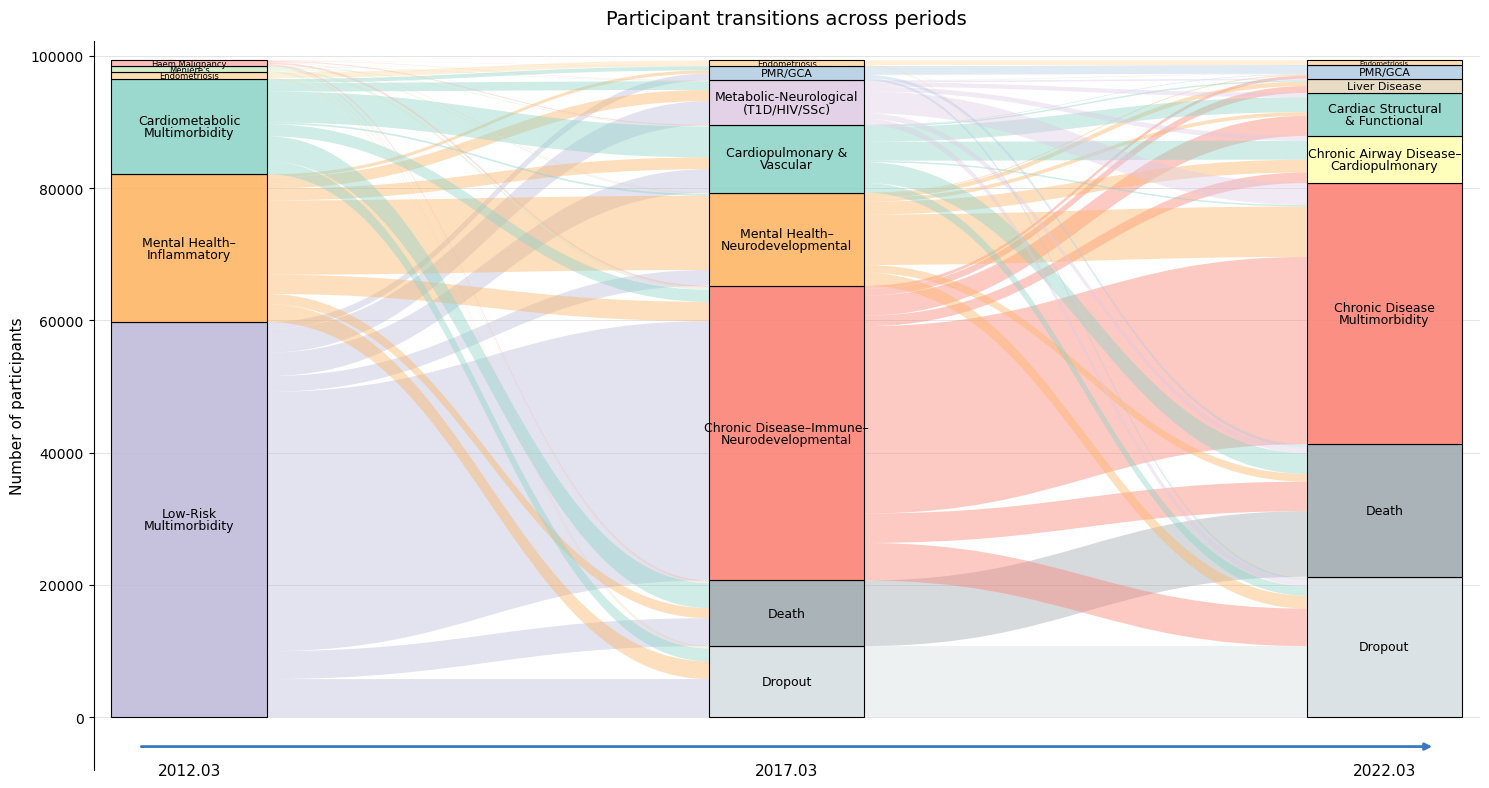

{'transition_counts_csv': 'period_transition_custom_params_results/period_transition_alluvial_custom_params_ordered_transition_counts.csv',
 'state_order_csv': 'period_transition_custom_params_results/period_transition_alluvial_custom_params_ordered_state_order.csv',
 'png': 'period_transition_custom_params_results/period_transition_alluvial_custom_params_ordered.png'}

In [47]:
period_label_map = {
    "before_2012_03": "2012.03",
    "2012_03_to_2017_03": "2017.03",
    "after_2017_03": "2022.03",
}

plot_state_df = period_state_df[
    period_state_df["before_2012_03"].str.startswith("Cluster", na=False)
].copy()

fig, transition_df, alluvial_files = plot_period_transition_alluvial(
    state_df=plot_state_df,
    period_order=period_order,
    title="Participant transitions across periods",
    output_dir="period_transition_custom_params_results",
    output_name="period_transition_alluvial_custom_params_ordered",
    period_label_map=period_label_map,
    state_label_map=state_label_map,   
    save_html=False,
    save_png=True,
    show_plot=True,
    figsize=(15, 8),
)

alluvial_files

In [48]:
transition_df.head(20)


,source_period,source_state,target_period,target_state,n
0,before_2012_03,Cluster 1,2012_03_to_2017_03,Cluster 1,267
1,before_2012_03,Cluster 1,2012_03_to_2017_03,Cluster 2,590
2,before_2012_03,Cluster 1,2012_03_to_2017_03,Cluster 3,4673
3,before_2012_03,Cluster 1,2012_03_to_2017_03,Cluster 4,1827
4,before_2012_03,Cluster 1,2012_03_to_2017_03,Cluster 5,1304
5,before_2012_03,Cluster 1,2012_03_to_2017_03,Death,3795
6,before_2012_03,Cluster 1,2012_03_to_2017_03,Dropout,1950
7,before_2012_03,Cluster 2,2012_03_to_2017_03,Cluster 1,56
8,before_2012_03,Cluster 2,2012_03_to_2017_03,Cluster 2,33
9,before_2012_03,Cluster 2,2012_03_to_2017_03,Cluster 3,146


In [49]:
period_name = "before_2012_03"

label_file = Path(
    "before_2012_03_hyperparameter_tuning_results/"
    "mca53_euclidean_kmeans_bs4096_ninit10_labels_K6.npy"
)

if not label_file.exists():
    label_file = Path(r"C:\Users\li\Documents") / label_file

labels = np.load(label_file)

disease_data = period_samples[period_name].active_disease_data
X = disease_data.X_numeric.copy()
disease_cols = disease_data.disease_cols

if len(labels) != len(X):
    raise ValueError(
        f"labels length does not match disease matrix: "
        f"labels={len(labels)}, X={len(X)}"
    )

df = X.copy()
df["cluster"] = labels

records = []

for disease in disease_cols:
    disease_mask = df[disease] == 1
    total_disease_count = int(disease_mask.sum())

    row = {
        "disease": disease,
        "total_disease_count": total_disease_count,
    }

    for cluster_id in sorted(np.unique(labels)):
        cluster_disease_count = int(
            ((df["cluster"] == cluster_id) & disease_mask).sum()
        )

        if total_disease_count > 0:
            cluster_share = cluster_disease_count / total_disease_count * 100
        else:
            cluster_share = 0

        row[f"cluster_{cluster_id}_count"] = cluster_disease_count
        row[f"cluster_{cluster_id}_share_percent"] = cluster_share

    records.append(row)

result_df = pd.DataFrame(records)

result_df["disease"] = (
    result_df["disease"]
    .str.replace("B_MEDI:", "", regex=False)
    .str.replace("B.M.", "", regex=False)
)

result_df = result_df.sort_values(
    by="total_disease_count",
    ascending=True
).reset_index(drop=True)

output_dir = Path("disease_distribution_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "before_2012_03_mca53_k6_disease_distribution_across_clusters.csv"

try:
    result_df.to_csv(output_file, index=False, encoding="utf-8-sig")
except PermissionError:
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    output_file = output_dir / f"before_2012_03_mca53_k6_disease_distribution_across_clusters_{timestamp}.csv"
    result_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Saved to: {output_file.resolve()}")
result_df


Saved to: /Users/liuyiwei/final_essay/disease_distribution_outputs/before_2012_03_mca53_k6_disease_distribution_across_clusters.csv


,disease,total_disease_count,cluster_0_count,cluster_0_share_percent,cluster_1_count,cluster_1_share_percent,cluster_2_count,cluster_2_share_percent,cluster_3_count,cluster_3_share_percent,cluster_4_count,cluster_4_share_percent,cluster_5_count,cluster_5_share_percent
0,SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,12,2,16.666667,0,0.000000,9,75.000000,0,0.000000,0,0.000000,1,8.333333
1,AUTISM_BIRM_CAM:19,25,1,4.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,24,96.000000
2,CYSTICFIBROSIS_BIRM_CAM:38,26,0,0.000000,26,100.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
3,DOWNSSYNDROME_BIRM_CAM:59,55,0,0.000000,1,1.818182,52,94.545455,0,0.000000,0,0.000000,2,3.636364
4,ADDISON_DISEASE_BIRM_CAM:54,69,12,17.391304,0,0.000000,32,46.376812,1,1.449275,4,5.797101,20,28.985507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,ATOPICECZEMA_BIRM_CAM:39,17906,2751,15.363565,158,0.882386,6965,38.897576,202,1.128113,198,1.105775,7632,42.622585
69,ANXIETY_BIRM_CAM:15,18014,1877,10.419674,136,0.754968,2430,13.489508,274,1.521039,242,1.343400,13055,72.471411
70,DEPRESSION_BIRM_CAM:14,23881,2631,11.017127,190,0.795612,4804,20.116411,379,1.587036,276,1.155730,15601,65.328085
71,OSTEOARTHRITIS_MM_BIRM_CAM:43,33103,7250,21.901338,303,0.915325,15907,48.053047,318,0.960638,445,1.344289,8880,26.825363


In [50]:
period_name = "2012_03_to_2017_03"
label_file = Path(
    "2012_03_to_2017_03_hyperparameter_tuning_results/"
    "mca53_euclidean_kmeans_bs8192_ninit20_labels_K6.npy"
)
if not label_file.exists():
    label_file = Path(r"C:\Users\li\Documents") / label_file
labels = np.load(label_file)
disease_data = period_samples[period_name].active_disease_data
X = disease_data.X_numeric.copy()
disease_cols = disease_data.disease_cols
if len(labels) != len(X):
    raise ValueError(
        f"labels length does not match disease matrix: "
        f"labels={len(labels)}, X={len(X)}"
    )
df = X.copy()
df["cluster"] = labels
records = []
for disease in disease_cols:
    disease_mask = df[disease] == 1
    total_disease_count = int(disease_mask.sum())
    row = {
        "disease": disease,
        "total_disease_count": total_disease_count,
    }
    for cluster_id in sorted(np.unique(labels)):
        cluster_disease_count = int(
            ((df["cluster"] == cluster_id) & disease_mask).sum()
        )
        if total_disease_count > 0:
            cluster_share = cluster_disease_count / total_disease_count * 100
        else:
            cluster_share = 0
        row[f"cluster_{cluster_id}_count"] = cluster_disease_count
        row[f"cluster_{cluster_id}_share_percent"] = cluster_share
    records.append(row)
result_df = pd.DataFrame(records)
result_df["disease"] = (
    result_df["disease"]
    .str.replace("B_MEDI:", "", regex=False)
    .str.replace("B.M.", "", regex=False)
)
result_df = result_df.sort_values(
    by="total_disease_count",
    ascending=True
).reset_index(drop=True)
output_file = "2012_03_to_2017_03_mca53_k6_disease_distribution_across_clusters.csv"
result_df.to_csv(output_file, index=False)
result_df

,disease,total_disease_count,cluster_0_count,cluster_0_share_percent,cluster_1_count,cluster_1_share_percent,cluster_2_count,cluster_2_share_percent,cluster_3_count,cluster_3_share_percent,cluster_4_count,cluster_4_share_percent,cluster_5_count,cluster_5_share_percent
0,SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,9,0,0.000000,9,100.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
1,CYSTICFIBROSIS_BIRM_CAM:38,20,0,0.000000,20,100.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
2,DOWNSSYNDROME_BIRM_CAM:59,32,1,3.125000,0,0.000000,0,0.000000,31,96.875000,0,0.000000,0,0.000000
3,AUTISM_BIRM_CAM:19,33,33,100.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
4,ADDISON_DISEASE_BIRM_CAM:54,69,4,5.797101,1,1.449275,23,33.333333,29,42.028986,11,15.942029,1,1.449275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,ATOPICECZEMA_BIRM_CAM:39,16969,3485,20.537451,514,3.029053,2520,14.850610,8680,51.152101,1561,9.199128,209,1.231658
69,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,17416,2700,15.502986,645,3.703491,3396,19.499311,8921,51.223013,1621,9.307533,133,0.763666
70,DEPRESSION_BIRM_CAM:14,21315,11644,54.628196,527,2.472437,2432,11.409805,4405,20.666198,1954,9.167253,353,1.656111
71,OSTEOARTHRITIS_MM_BIRM_CAM:43,30951,5472,17.679558,1262,4.077413,5154,16.652128,15290,49.400666,3440,11.114342,333,1.075894


In [51]:
period_name = "after_2017_03"
label_file = Path(
    "after_2017_03_hyperparameter_tuning_results/"
    "mca61_euclidean_kmeans_bs8192_ninit5_labels_K6.npy"
)
if not label_file.exists():
    label_file = Path(r"C:\Users\li\Documents") / label_file
labels = np.load(label_file)
disease_data = period_samples[period_name].active_disease_data
X = disease_data.X_numeric.copy()
disease_cols = disease_data.disease_cols
if len(labels) != len(X):
    raise ValueError(
        f"labels length does not match disease matrix: "
        f"labels={len(labels)}, X={len(X)}"
    )
df = X.copy()
df["cluster"] = labels
records = []
for disease in disease_cols:
    disease_mask = df[disease] == 1
    total_disease_count = int(disease_mask.sum())
    row = {
        "disease": disease,
        "total_disease_count": total_disease_count,
    }
    for cluster_id in sorted(np.unique(labels)):
        cluster_disease_count = int(
            ((df["cluster"] == cluster_id) & disease_mask).sum()
        )
        if total_disease_count > 0:
            cluster_share = cluster_disease_count / total_disease_count * 100
        else:
            cluster_share = 0
        row[f"cluster_{cluster_id}_count"] = cluster_disease_count
        row[f"cluster_{cluster_id}_share_percent"] = cluster_share
    records.append(row)
result_df = pd.DataFrame(records)
result_df["disease"] = (
    result_df["disease"]
    .str.replace("B_MEDI:", "", regex=False)
    .str.replace("B.M.", "", regex=False)
)
result_df = result_df.sort_values(
    by="total_disease_count",
    ascending=True
).reset_index(drop=True)
output_file = "after_2017_03_mca53_k6_disease_distribution_across_clusters.csv"
result_df.to_csv(output_file, index=False)
result_df

,disease,total_disease_count,cluster_0_count,cluster_0_share_percent,cluster_1_count,cluster_1_share_percent,cluster_2_count,cluster_2_share_percent,cluster_3_count,cluster_3_share_percent,cluster_4_count,cluster_4_share_percent,cluster_5_count,cluster_5_share_percent
0,SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,7,0,0.000000,6,85.714286,0,0.000000,1,14.285714,0,0.000000,0,0.000000
1,DOWNSSYNDROME_BIRM_CAM:59,11,0,0.000000,10,90.909091,1,9.090909,0,0.000000,0,0.000000,0,0.000000
2,CYSTICFIBROSIS_BIRM_CAM:38,18,1,5.555556,11,61.111111,1,5.555556,0,0.000000,0,0.000000,5,27.777778
3,AUTISM_BIRM_CAM:19,36,1,2.777778,27,75.000000,3,8.333333,2,5.555556,0,0.000000,3,8.333333
4,SYSTEMIC_SCLEROSIS_MM_BIRM_CAM:48,62,1,1.612903,36,58.064516,11,17.741935,2,3.225806,3,4.838710,9,14.516129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,ANXIETY_BIRM_CAM:15,14814,255,1.721345,9659,65.201836,1201,8.107196,676,4.563251,444,2.997165,2579,17.409208
69,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,15761,125,0.793097,9819,62.299346,2344,14.872153,575,3.648246,691,4.384240,2207,14.002919
70,DEPRESSION_BIRM_CAM:14,17666,311,1.760444,11130,63.002377,1427,8.077663,846,4.788860,569,3.220876,3383,19.149779
71,OSTEOARTHRITIS_MM_BIRM_CAM:43,27116,336,1.239121,17198,63.423809,3446,12.708364,1032,3.805871,1277,4.709397,3827,14.113439


In [52]:
#Bubble Plot
def plot_transition_contribution_bubble(
    state_df,
    source_period,
    target_period,
    source_label="2012.03",
    target_label="2017.03",
    output_dir="period_transition_custom_params_results",
    output_name=None,
    include_source_status=("Cluster",),
    target_status_order=("Cluster", "Death", "Dropout"),
    figsize=(11, 8),
    dpi=300,
    show_ci=True,
    show_plot=True,
    state_label_map=None,        
):
    """
    Bubble plot for transition contribution between two periods.

    Each column is a target-period state. Each cell shows the percentage of
    participants in that target state who came from the source-period state.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    data = state_df[[source_period, target_period]].dropna().copy()
    data[source_period] = data[source_period].astype(str)
    data[target_period] = data[target_period].astype(str)

    def _keep_state(state, allowed):
        if "Cluster" in allowed and state.startswith("Cluster"):
            return True
        return state in allowed

    data = data[data[source_period].map(lambda x: _keep_state(x, include_source_status))]

    def _state_sort_key(state, counts):
        if state.startswith("Cluster"):
            return (0, -counts.get(state, 0), state)
        if state == "Death":
            return (1, 0, state)
        if state == "Dropout":
            return (2, 0, state)
        return (3, 0, state)

    source_counts = data[source_period].value_counts()
    target_counts = data[target_period].value_counts()

    source_states = sorted(source_counts.index.tolist(), key=lambda s: _state_sort_key(s, source_counts))

    target_states = []
    if "Cluster" in target_status_order:
        clusters = [s for s in target_counts.index.tolist() if s.startswith("Cluster")]
        target_states.extend(sorted(clusters, key=lambda s: (-target_counts.get(s, 0), s)))
    for state in target_status_order:
        if state != "Cluster" and state in target_counts.index:
            target_states.append(state)

    flow = (
        data.groupby([source_period, target_period])
        .size()
        .reset_index(name="n")
    )
    target_totals = data.groupby(target_period).size().rename("target_total")
    flow = flow.merge(target_totals, left_on=target_period, right_index=True)
    flow["percent"] = flow["n"] / flow["target_total"] * 100

    # Approximate 95% CI for a proportion inside each target state.
    p = flow["n"] / flow["target_total"]
    se = np.sqrt(p * (1 - p) / flow["target_total"])
    flow["ci_low"] = np.maximum(0, (p - 1.96 * se) * 100)
    flow["ci_high"] = np.minimum(100, (p + 1.96 * se) * 100)

    plot_df = (
        pd.MultiIndex.from_product([source_states, target_states], names=[source_period, target_period])
        .to_frame(index=False)
        .merge(flow, on=[source_period, target_period], how="left")
    )
    for col in ["n", "target_total", "percent", "ci_low", "ci_high"]:
        plot_df[col] = plot_df[col].fillna(0)

    x_map = {state: i for i, state in enumerate(target_states)}
    y_map = {state: i for i, state in enumerate(source_states)}
    plot_df["x"] = plot_df[target_period].map(x_map)
    plot_df["y"] = plot_df[source_period].map(y_map)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("#e9e9e9")
    ax.grid(True, color="white", linestyle="--", linewidth=1.2)
    ax.set_axisbelow(True)

    sizes = np.maximum(plot_df["percent"], 0) * 70
    ax.scatter(
        plot_df["x"],
        plot_df["y"],
        s=sizes,
        color="#6fa8dc",
        alpha=0.82,
        edgecolor="none",
    )

    for _, row in plot_df.iterrows():
        if row["target_total"] <= 0:
            label = "0.0"
        elif show_ci:
            label = f"{row['percent']:.1f}\n({row['ci_low']:.1f}-{row['ci_high']:.1f})"
        else:
            label = f"{row['percent']:.1f}"
        ax.text(
            row["x"],
            row["y"],
            label,
            ha="center",
            va="center",
            fontsize=8.5,
            color="black",
        )

    if state_label_map is None:
        state_label_map = {}
    ax.set_xticks(range(len(target_states)))
    ax.set_xticklabels(
        [state_label_map.get((target_period, s), s) for s in target_states],
        rotation=45, ha="right",
    )
    ax.set_yticks(range(len(source_states)))
    ax.set_yticklabels(
        [state_label_map.get((source_period, s), s) for s in source_states]
    )
    ax.invert_yaxis()

    ax.set_xlabel(f"At {target_label}", labelpad=10)
    ax.set_ylabel(f"From {source_label}", labelpad=10)
    ax.set_title(f"Contribution of {source_label} clusters to {target_label} states", pad=12)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if output_name is None:
        output_name = f"transition_contribution_bubble_{source_period}_to_{target_period}"
    output_files = {
        "png": str((output_dir / f"{output_name}.png").resolve()),
        "csv": str((output_dir / f"{output_name}.csv").resolve()),
    }
    fig.savefig(output_files["png"], dpi=dpi, bbox_inches="tight")
    plot_df.to_csv(output_files["csv"], index=False, encoding="utf-8-sig")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return fig, plot_df, output_files


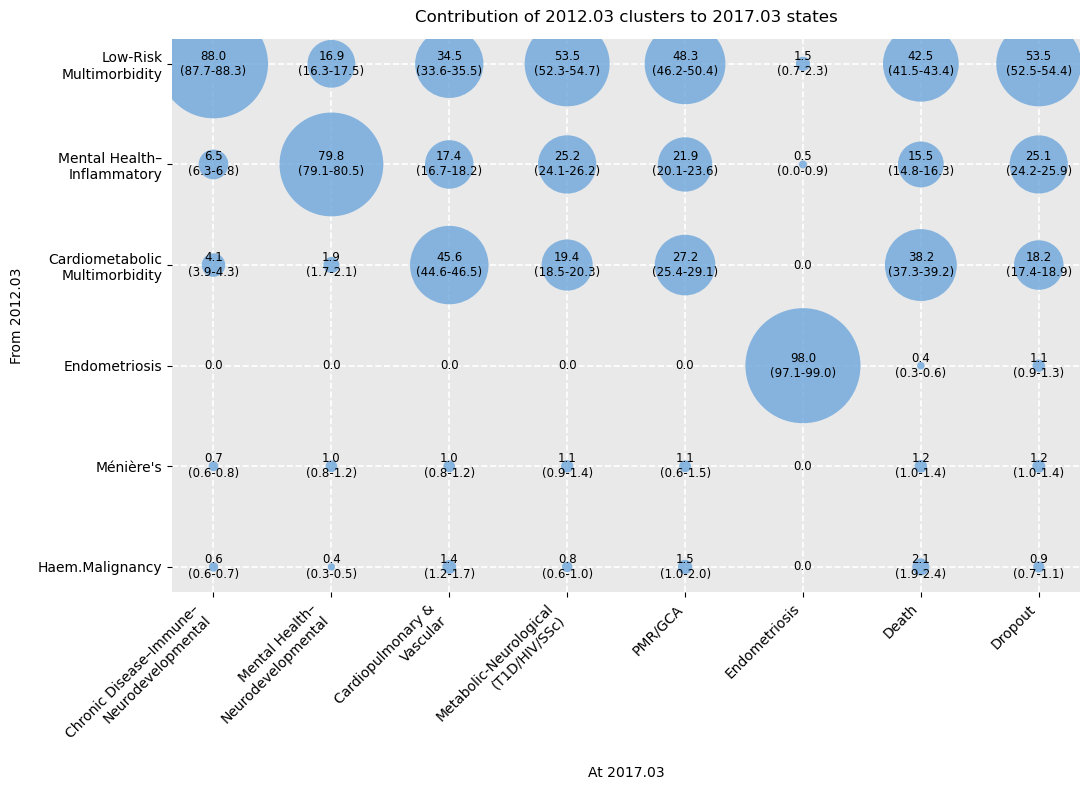

{'png': '/Users/liuyiwei/final_essay/period_transition_custom_params_results/transition_contribution_bubble_2012_03_to_2017_03.png',
 'csv': '/Users/liuyiwei/final_essay/period_transition_custom_params_results/transition_contribution_bubble_2012_03_to_2017_03.csv'}

In [53]:
fig, contribution_2012_to_2017_df, contribution_2012_to_2017_files = plot_transition_contribution_bubble(
    state_df=period_state_df,
    source_period="before_2012_03",
    target_period="2012_03_to_2017_03",
    source_label="2012.03",
    target_label="2017.03",
    output_dir="period_transition_custom_params_results",
    output_name="transition_contribution_bubble_2012_03_to_2017_03",
    state_label_map=state_label_map,   
    show_ci=True,
    show_plot=True,
)

contribution_2012_to_2017_files


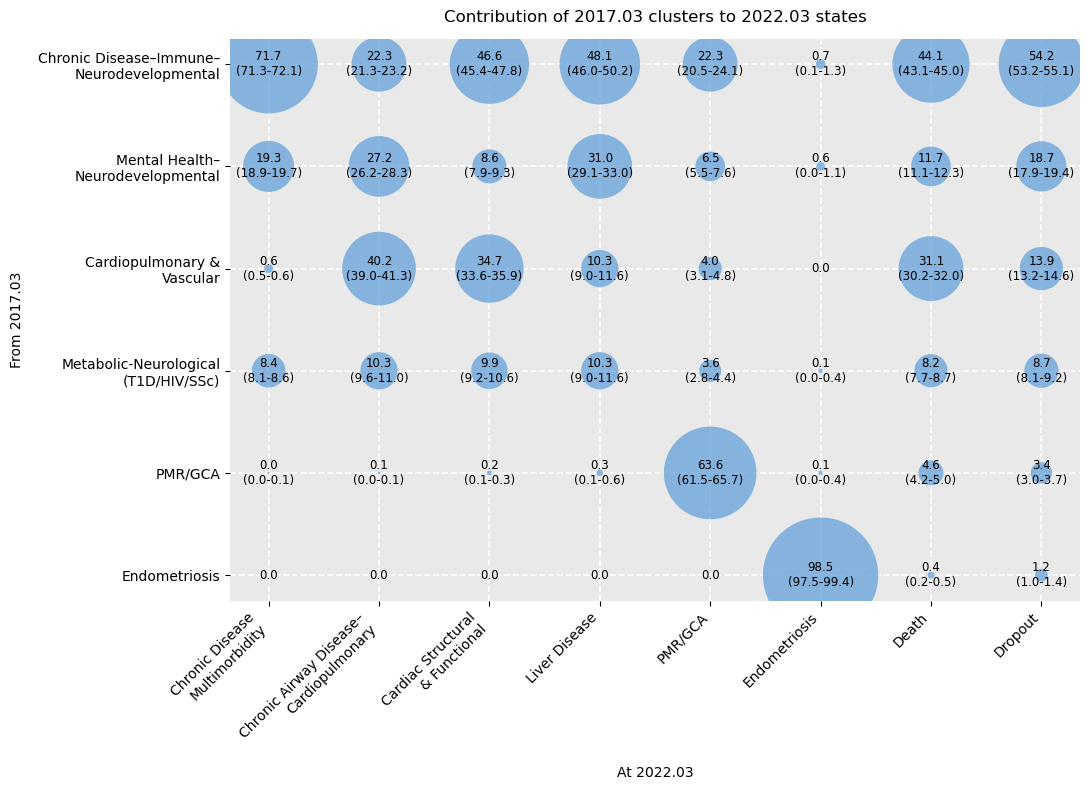

{'png': '/Users/liuyiwei/final_essay/period_transition_custom_params_results/transition_contribution_bubble_2017_03_to_2022_03.png',
 'csv': '/Users/liuyiwei/final_essay/period_transition_custom_params_results/transition_contribution_bubble_2017_03_to_2022_03.csv'}

In [54]:
fig, contribution_2017_to_2022_df, contribution_2017_to_2022_files = plot_transition_contribution_bubble(
    state_df=period_state_df,
    source_period="2012_03_to_2017_03",
    target_period="after_2017_03",
    source_label="2017.03",
    target_label="2022.03",
    output_dir="period_transition_custom_params_results",
    output_name="transition_contribution_bubble_2017_03_to_2022_03",
    state_label_map=state_label_map,   
    show_ci=True,
    show_plot=True,
)

contribution_2017_to_2022_files
